# Lab 1 — Preprocessing of Multimodal Physiological Signals (WESAD)

**Estimated total time: ~3 hours**

---

## Overview

In this lab you will build a **complete preprocessing pipeline** for physiological signals from the **WESAD** dataset (Wearable Stress and Affect Detection).  
Starting from raw sensor data, you will apply all the techniques covered in lectures 2.1–2.5 to produce a **clean feature matrix** ready for machine learning classification in future labs.

**What you will produce:** CSV files containing extracted and selected features for multiple subjects — the direct input for Lab 2 (ML classification).

**Signals analysed:**

| Signal | Sensor | Sampling rate |
|--------|--------|---------------|
| ECG | Chest (RespiBAN) | 700 Hz |
| EDA | Chest (RespiBAN) | 700 Hz |
| EDA | Wrist (Empatica E4) | 4 Hz |
| BVP (PPG) | Wrist (Empatica E4) | 64 Hz |
| ACC (magnitude) | Wrist (Empatica E4) | 32 Hz |

**Conditions:** Baseline / Rest (1) · Stress (2) · Amusement (3)

---

## Learning Objectives

By the end of this lab you will be able to:

1. Inspect physiological signals for missing values and artefacts
2. Apply and compare imputation strategies (mean, median, mean ± noise, interpolation)
3. Detect outliers using z-score and IQR methods (global and per-condition)
4. Design and apply Butterworth filters with `scipy.signal`
5. Resample signals from different sensors to a common frequency
6. Apply and compare z-score and min-max normalisation
7. Segment signals using sliding windows with configurable overlap
8. Extract time-domain and frequency-domain features from segments
9. Build a feature extraction pipeline end-to-end
10. Apply and compare feature selection methods (variance threshold, correlation, statistical tests, mutual information, mRMR)
11. Apply PCA and t-SNE for dimensionality reduction and visualisation
12. Produce a multi-subject feature matrix (CSV) for future labs

---

## Timeline

| Block | Section | Time | TODOs |
|-------|---------|------|-------|
| 0 | Setup & Data Loading | 10 min | — |
| 1 | Data Quality + Missing Values + Imputation | 25 min | TODO 1–2 |
| 2 | Outlier Detection & Handling | 20 min | TODO 3 |
| — | *Break* | 5 min | — |
| 3 | Filtering | 15 min | TODO 4 |
| 4 | Resampling | 12 min | TODO 5 |
| 5 | Normalisation | 10 min | TODO 6 |
| 6 | Segmentation | 12 min | TODO 7 |
| — | *Break* | 5 min | — |
| 7 | Feature Extraction | 30 min | TODO 8–10 |
| 8 | Feature Selection & Reduction | 30 min | TODO 11–13 |
| — | *Break* | 5 min | — |
| 9 | Multi-Subject Pipeline & CSV Export | 25 min | TODO 14–15 |
| 10 | Wrap-up | 5 min | — |
| 11 | *(Optional)* EDA Chest vs Wrist | 15–20 min | TODO 16 |

## Prerequisites

- Python basics (numpy, pandas, matplotlib)
- Introductory WESAD notebook (dataset structure, signals, labels)
- Lecture concepts: filtering, sampling theorem, z-score, sliding windows, feature extraction / selection


## Section 0 — Setup & Data Loading

⏱ **Estimated time: 10 min** · *100 % provided — just run the cells*

**Install required packages** (some are already available in the Kaggle environment)

In [1]:
!pip install -q neurokit2
!pip install -q mrmr-selection 2>/dev/null || echo "mrmr-selection not available — a fallback will be used in Section 8"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 17.0 MB/s eta 0:00:0000:01


**Import modules**

In [2]:
import numpy as np
import pandas as pd
import pickle, os, warnings
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk

from scipy.signal import butter, filtfilt, welch, resample
from scipy.stats import (ttest_ind, mannwhitneyu, f_oneway,
                          kruskal, skew, kurtosis as scipy_kurtosis)

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 4)
sns.set_style("whitegrid")
print("All imports OK ✓")

All imports OK ✓


**Load WESAD data**

The dataset is linked as a Kaggle dataset and available read-only under `/kaggle/input/`. Output files will be saved to `/kaggle/working/`.

In [3]:
DATA_PATH = '/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD'

with open(os.path.join(DATA_PATH, 'S2', 'S2.pkl'), 'rb') as f:
    data_s2 = pickle.load(f, encoding='latin1')

chest  = data_s2['signal']['chest']
wrist  = data_s2['signal']['wrist']
labels = data_s2['label']

print(f"Labels shape:   {labels.shape}")
print(f"Unique labels:  {np.unique(labels)}")
print(f"Chest keys:     {list(chest.keys())}")
print(f"Wrist keys:     {list(wrist.keys())}")

Labels shape:   (4255300,)
Unique labels:  [0 1 2 3 4 6 7]
Chest keys:     ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']
Wrist keys:     ['ACC', 'BVP', 'EDA', 'TEMP']


**Constants and sampling rates**

In [6]:
REST   = 1;  STRESS = 2;  AMUSE = 3
CONDITION_NAMES = {REST: 'Rest', STRESS: 'Stress', AMUSE: 'Amusement'}

FS_CHEST     = 700
FS_WRIST_BVP = 64
FS_WRIST_EDA = 4
FS_WRIST_ACC = 32
FS_TARGET    = 64          # common wrist target rate

WINDOW_SEC = 60
OVERLAP    = 0.5


**Helper functions (provided)**

These utilities are used throughout the lab — read through and execute them, but **do not modify**.


In [8]:
# ════════════════════════════════════════════════════════════════
# HELPERS  (provided)
# ════════════════════════════════════════════════════════════════


# me: this function acts as a "Time-Based Filter" to isolate specific parts of a long recording.
def extract_condition(signal_array, labels, condition,
                      fs_signal, fs_labels=FS_CHEST, max_minutes=5):
    sig = np.squeeze(signal_array) # me: Removes any unnecessary single-dimensions
    n   = sig.shape[0] # me: Stores the total number of samples in the signal.
    if fs_signal == fs_labels:
        idx  = np.arange(min(n, len(labels))) # me: Creates a list of indices up to the length of the shorter array
        mask = labels[idx] == condition # me: Creates a "Boolean" where the label matches your target condition.
        data = sig[idx][mask] # me: "grab" only the signal values where the label was True.
    else:
        times     = np.arange(n) / fs_signal # me: Converts the signal sample indices into a "Time in Seconds" array.
        label_idx = np.clip((times * fs_labels).astype(int), 0, len(labels)-1) # me: Multiplies the time by the label frequency to find which label index corresponds to that exact moment.
        mask = labels[label_idx] == condition
        data = sig[mask]
    return data[:int(max_minutes * 60 * fs_signal)]


# me : This function is the "Visual Quality Check." looking at thhe signal in the Time Domain
def plot_comparison(original, processed, fs,
                    title="Signal comparison", seconds=10):
    n = min(int(seconds * fs), len(original), len(processed))
    t = np.arange(n) / fs
    plt.figure(figsize=(12, 4))
    plt.plot(t, original[:n], alpha=0.5, label='Original', linewidth=0.8)
    plt.plot(t, processed[:n], label='Processed', linewidth=0.8)
    plt.xlabel('Time (s)');  plt.ylabel('Amplitude')
    plt.title(title);  plt.legend();  plt.tight_layout();  plt.show()


# me: this function is looking at the signal in the Frequency Domain  
def plot_psd(signal_data, fs, title="PSD", max_freq=None):
    freqs, psd = welch(signal_data, fs=fs, nperseg=min(1024, len(signal_data)))
    plt.figure(figsize=(10, 4))
    m = (freqs <= max_freq) if max_freq else np.ones(len(freqs), bool)
    plt.semilogy(freqs[m], psd[m])
    plt.xlabel('Frequency (Hz)');  plt.ylabel('PSD (V²/Hz)')
    plt.title(title);  plt.tight_layout();  plt.show()


# This function is designed to calculate the Magnitude (the "total strength") of an accelerometer signal.
def _acc_mag(a):
    return np.sqrt(np.sum(a**2, axis=1)) if a.ndim == 2 else a


#This function is a "Repair Kit" for your data. In medical sensors, 
#"outliers" are often spikes caused by a sensor losing contact with the skin or a sudden movement. 
#If you just leave those spikes in, they’ll confuse your AI. 
#If you just delete them, you’ll have "holes" in your timeline.
#This function finds a middle ground: it removes the bad data and "guesses" what should have been there.
def clamp_outliers(signal, outlier_mask):
    result = signal.copy().astype(float)
    result[outlier_mask] = np.nan
    return pd.Series(result).interpolate(method='linear').bfill().ffill().values

print("Helpers loaded ✓")


Helpers loaded ✓


**Extract signals for each condition**

In [9]:
# ── Chest (700 Hz) ──────────────────────────────────────────────
ecg_rest   = extract_condition(chest['ECG'], labels, REST,   FS_CHEST)
ecg_stress = extract_condition(chest['ECG'], labels, STRESS, FS_CHEST)
ecg_amuse  = extract_condition(chest['ECG'], labels, AMUSE,  FS_CHEST)

eda_chest_rest   = extract_condition(chest['EDA'], labels, REST,   FS_CHEST)
eda_chest_stress = extract_condition(chest['EDA'], labels, STRESS, FS_CHEST)
eda_chest_amuse  = extract_condition(chest['EDA'], labels, AMUSE,  FS_CHEST)

# ── Wrist (various rates) ──────────────────────────────────────
bvp_rest   = extract_condition(wrist['BVP'], labels, REST,   FS_WRIST_BVP)
bvp_stress = extract_condition(wrist['BVP'], labels, STRESS, FS_WRIST_BVP)
bvp_amuse  = extract_condition(wrist['BVP'], labels, AMUSE,  FS_WRIST_BVP)

eda_wrist_rest   = extract_condition(wrist['EDA'], labels, REST,   FS_WRIST_EDA)
eda_wrist_stress = extract_condition(wrist['EDA'], labels, STRESS, FS_WRIST_EDA)
eda_wrist_amuse  = extract_condition(wrist['EDA'], labels, AMUSE,  FS_WRIST_EDA)

acc_rest   = _acc_mag(extract_condition(wrist['ACC'], labels, REST,   FS_WRIST_ACC))
acc_stress = _acc_mag(extract_condition(wrist['ACC'], labels, STRESS, FS_WRIST_ACC))
acc_amuse  = _acc_mag(extract_condition(wrist['ACC'], labels, AMUSE,  FS_WRIST_ACC))

print("Signal shapes (up to 5 min each):")
for name, sig, fs in [
    ("ECG rest",       ecg_rest,       FS_CHEST),
    ("EDA chest rest", eda_chest_rest, FS_CHEST),
    ("BVP wrist rest", bvp_rest,       FS_WRIST_BVP),
    ("EDA wrist rest", eda_wrist_rest, FS_WRIST_EDA),
    ("ACC wrist rest", acc_rest,       FS_WRIST_ACC),
]:
    print(f"  {name:20s}  shape={str(sig.shape):12s}  fs={fs:4d} Hz  "
          f"duration={len(sig)/fs:.1f} s")


Signal shapes (up to 5 min each):
  ECG rest              shape=(210000,)     fs= 700 Hz  duration=300.0 s
  EDA chest rest        shape=(210000,)     fs= 700 Hz  duration=300.0 s
  BVP wrist rest        shape=(19200,)      fs=  64 Hz  duration=300.0 s
  EDA wrist rest        shape=(1200,)       fs=   4 Hz  duration=300.0 s
  ACC wrist rest        shape=(9600,)       fs=  32 Hz  duration=300.0 s


---
## Section 1 — Data Quality & Missing Value Handling

⏱ **Estimated time: 25 min** · TODOs 1–2

> **Connection to lectures:** In the Missing Values lecture you handled NaN on tabular data (Iris) using mean, median, and mean ± std imputation, observing how each strategy affected the distribution per class.  
> Here you apply the **same ideas to physiological signals**, where **temporal continuity** adds an extra dimension: interpolation-based methods become particularly relevant.


### TODO 1 — Signal Quality Check (~8 min)

Implement `check_signal_quality` to produce a summary table for a dictionary of signals.  
For each signal compute: **length, dtype, #NaN, #Inf, min, max, mean, std**.


In [17]:
def check_signal_quality(signal_dict):
    """Return a DataFrame summarising the quality of each signal.

    Parameters
    ----------
    signal_dict : dict[str, np.ndarray]

    Returns
    -------
    pd.DataFrame with columns:
        signal, length, dtype, n_nan, n_inf, min, max, mean, std
    """
    rows = []
    for name, sig in signal_dict.items():
        # ── TODO 1 ──────────────────────────────
        row = {
            'signal': name,
            'length': len(sig),
            'dtype' : sig.dtype,
            
            'n_nan' : np.isnan(sig).sum(),
            'n_inf' : np.isinf(sig).sum(),
            # These count how many "broken" points are in your data
            
            'min' : np.nanmin(sig) if len(sig) > 0 else np.nan,
            #Standard np.min will return NaN if even one single value in your array is missing. 
            #By using the nan- versions, the function ignores the gaps and calculates the statistics 
            #based on the "good" data that remains.
            'max' : np.nanmax(sig) if len(sig) > 0 else np.nan,
            'mean' : np.nanmean(sig) if len(sig) > 0 else np.nan,
            'std' : np.nanstd(sig) if len(sig) > 0 else np.nan
        }
        rows.append(row)
    return pd.DataFrame(rows)


In [18]:
quality_chest = check_signal_quality({'ECG': ecg_rest, 'EDA_chest': eda_chest_rest})
quality_wrist = check_signal_quality({'BVP': bvp_rest, 'EDA_wrist': eda_wrist_rest, 'ACC': acc_rest})
print("=== Chest signals ===");  display(quality_chest)
print("\n=== Wrist signals ===");  display(quality_wrist)

# Checkpoint
assert quality_chest['length'].notna().all(), "Fill in the 'length' field"
assert quality_chest['n_nan'].sum() == 0, "WESAD should have no NaN"
print("✓ TODO 1 passed")


=== Chest signals ===


,signal,length,dtype,n_nan,n_inf,min,max,mean,std
0,ECG,210000,float64,0,0,-1.499405,1.415726,0.001269,0.153838
1,EDA_chest,210000,float64,0,0,2.121353,5.756760,3.628033,0.846028



=== Wrist signals ===


,signal,length,dtype,n_nan,n_inf,min,max,mean,std
0,BVP,19200,float64,0,0,-670.200000,554.770000,-0.023305,72.118615
1,EDA_wrist,1200,float64,0,0,0.362884,1.640539,0.719436,0.330937
2,ACC,9600,float64,0,0,28.618176,127.287077,63.512468,3.904364


✓ TODO 1 passed


### Simulating Missing Data

WESAD is clean, but real wearable data often has **gaps**. We inject ~5 % NaN into a 2s ECG segment and keep the original as **ground truth**.


In [20]:
np.random.seed(42)
ecg_segment_clean = ecg_rest[:2*FS_CHEST].copy()
ecg_segment_nan   = ecg_segment_clean.copy()
nan_idx = np.random.choice(len(ecg_segment_nan),
                           size=int(len(ecg_segment_nan)*0.05), replace=False)
# pich 5% of the dataset and destroy them
ecg_segment_nan[nan_idx] = np.nan
print(f"Segment: {len(ecg_segment_nan)} samples, "
      f"{np.isnan(ecg_segment_nan).sum()} NaN ({np.isnan(ecg_segment_nan).mean()*100:.1f}%)")


Segment: 1400 samples, 70 NaN (5.0%)


### TODO 2 — Imputation Methods (~15 min)

Implement the four imputation functions below. Each receives a 1-D array **with NaN** and returns a **copy** with NaN replaced.

| # | Method | Lecture equivalent |
|---|--------|--------------------|
| 1 | `impute_mean` | Global mean |
| 2 | `impute_median` | Global median |
| 3 | `impute_mean_noise` | mean ± std random noise |
| 4 | `impute_interpolation` | Linear interpolation (time-series) |

<details><summary><b>Hint 1</b> — impute_mean</summary>
`np.nanmean(signal)` computes the mean ignoring NaN. Replace NaN positions with that value.
</details>

<details><summary><b>Hint 2</b> — impute_mean_noise</summary>
`m, s = np.nanmean(signal), np.nanstd(signal)` → for each NaN: `np.random.uniform(m-s, m+s)`
</details>

<details><summary><b>Hint 3</b> — impute_interpolation</summary>
`pd.Series(signal).interpolate(method='linear').values`
</details>


In [28]:
def impute_mean(signal):
    # ── TODO 2a ─────────────────────────────────
    res = signal.copy()
    res[np.isnan(res)] = np.nanmean(signal)
    return res 

def impute_median(signal):
    # ── TODO 2b ─────────────────────────────────
    res = signal.copy()
    res[np.isnan(res)] = np.nanmedian(signal)
    return res 

def impute_mean_noise(signal):
    # ── TODO 2c ─────────────────────────────────
    res = signal.copy()
    nannn = np.isnan(res)
    mu = np.nanmean(signal)
    std = np.nanstd(signal)
    res[nannn] = np.random.normal(mu, std, size = nannn.sum())
    return res

def impute_interpolation(signal):
    # ── TODO 2d ─────────────────────────────────
    res = signal.copy()
    return pd.Series(signal).interpolate(method='linear').bfill().ffill().values


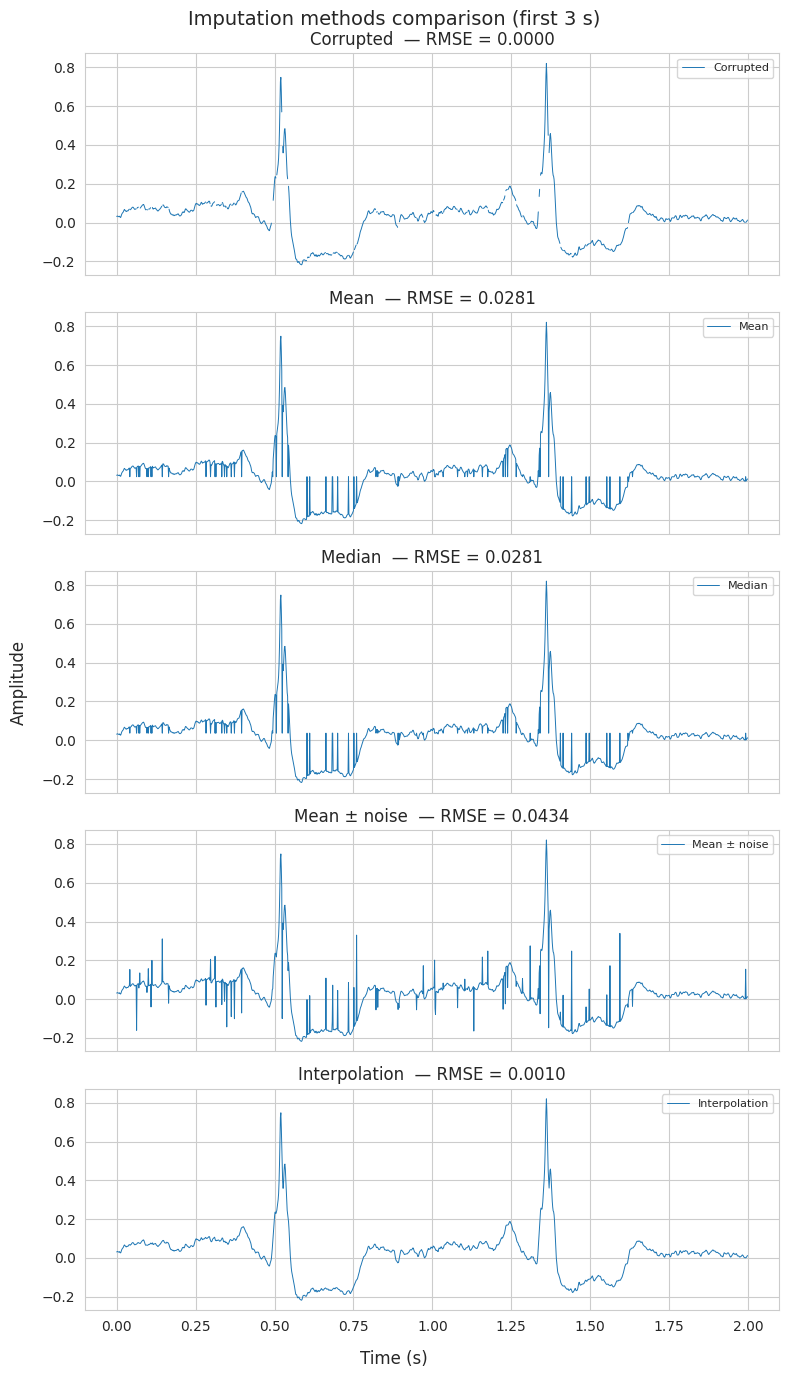

✓ TODO 2 passed


In [29]:
# ── Compare imputation methods (provided — run & interpret) ────
methods = {
    'Corrupted':      ecg_segment_nan,
    'Mean':          impute_mean(ecg_segment_nan),
    'Median':        impute_median(ecg_segment_nan),
    'Mean ± noise':  impute_mean_noise(ecg_segment_nan),
    'Interpolation': impute_interpolation(ecg_segment_nan),
}
fig, axes = plt.subplots(5, 1, figsize=(8, 14), sharex=True, sharey=True)
t = np.arange(len(ecg_segment_clean)) / FS_CHEST
for ax, (name, imp) in zip(axes.flat, methods.items()):
    rmse = np.sqrt(np.nanmean((ecg_segment_clean - imp)**2))
    ax.plot(t, imp, lw=.7, label=name)
    ax.set_title(f'{name}  — RMSE = {rmse:.4f}');  ax.legend(fontsize=8)
fig.supxlabel('Time (s)');  fig.supylabel('Amplitude')
fig.suptitle('Imputation methods comparison (first 3 s)', fontsize=14)
plt.tight_layout();  plt.show()

# Checkpoint
for n, imp in methods.items():
    if n!='Corrupted':
        assert not np.isnan(imp).any(), f"{n}: still has NaN!"  
rmse_i = np.sqrt(np.nanmean((ecg_segment_clean - methods['Interpolation'])**2))
rmse_m = np.sqrt(np.nanmean((ecg_segment_clean - methods['Mean'])**2))
assert rmse_i < rmse_m, "Interpolation should beat mean"
print("✓ TODO 2 passed")


### 🤔 Reflection

1. **Which method best preserves the ECG morphology? Why?**
2. **Why is interpolation preferable for temporal signals vs global mean?**
3. **Would interpolation still work for a 30 s gap? What alternative would you use?**

*Your answers:*

1. Answer: Interpolation.

Why: ECG signals are highly rhythmic and continuous. Since a heartbeat follows a predictable "path", interpolation connects the gap by looking at the points immediately before and after the missing segment. The other methods (mean/median) ignore the local rhythm and just "guess" based on the entire 5-minute recording, which results in flat lines that destroy the characteristic shape of the heart wave.

2. Why: Temporal (time-series) signals have a high "autocorrelation"—meaning the value at t=10.1 is likely very close to the value at t=10.0.

The Flaw of Global Mean: The global mean uses data from minutes ago to fill a gap happening right now. If your heart rate was 60 BPM at the start of the lab but is 100 BPM now during the "stress" phase, the global mean will be totally wrong for the current moment. Interpolation uses local context, which is much more relevant.

3. Answer: No, it would likely fail.

Why: A 30-second gap in a 700 Hz signal is 21,000 missing samples. In 30 seconds, a heart can beat 30 to 60 times. A straight line (linear interpolation) would completely miss all those heartbeats, creating a "flatline" that looks like the patient has passed away!

Alternatives:

Cyclic/Pattern Imputation: Use a "Search and Paste" method where you find a previous 30-second window of heartbeats from the same patient and "paste" it into the gap


---
## Section 2 — Outlier Detection & Handling

⏱ **Estimated time: 20 min** · TODO 3

> **Connection to lectures:** In the Outliers lecture you detected outliers on Iris using IQR, and discovered that **dividing by class** changed which points were outliers. The same applies here: Rest vs Stress have different distributions.


**Visualise the ECG distribution** 

Run the following code to observe distribution of the ECG signal.

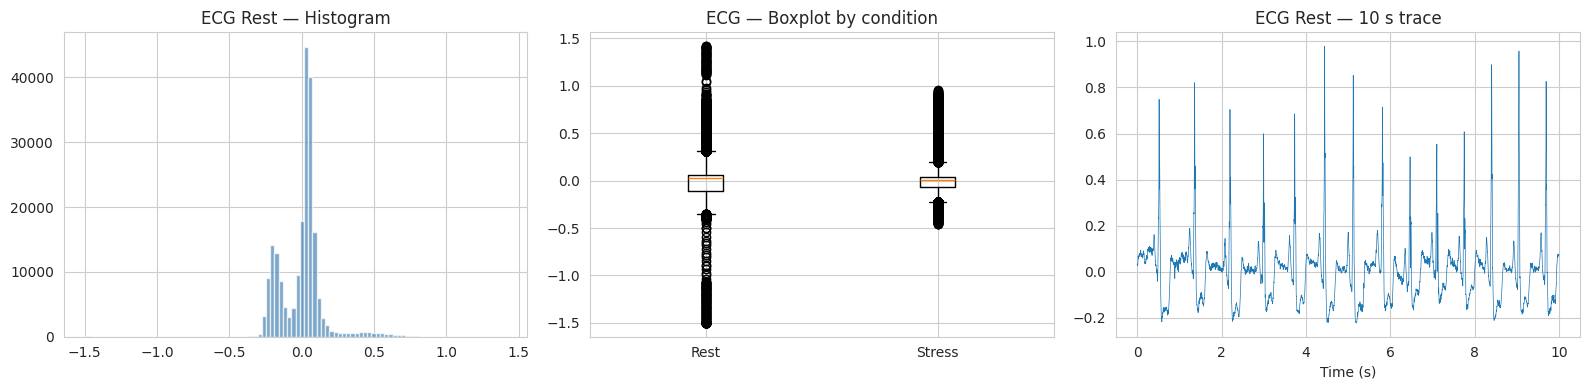

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(ecg_rest, bins=100, alpha=.7, color='steelblue')
axes[0].set_title('ECG Rest — Histogram')
axes[1].boxplot([ecg_rest, ecg_stress], labels=['Rest', 'Stress'])
axes[1].set_title('ECG — Boxplot by condition')
t10 = np.arange(10*FS_CHEST) / FS_CHEST
axes[2].plot(t10, ecg_rest[:10*FS_CHEST], lw=.5)
axes[2].set_title('ECG Rest — 10 s trace');  axes[2].set_xlabel('Time (s)')
plt.tight_layout();  plt.show()


### TODO 3 — Outlier Detection (~15 min)

Implement **z-score**-based and **IQR**-based outlier detection in the methods below. We will then apply them to the ECG.

<details><summary><b>Hint — z-score</b></summary>
`z = (signal - np.mean(signal)) / np.std(signal)` → `mask = np.abs(z) > threshold`
</details>
<details><summary><b>Hint — IQR</b></summary>
`Q1, Q3 = np.percentile(signal, [25, 75]); IQR = Q3-Q1;  mask = (signal < Q1-k*IQR) | (signal > Q3+k*IQR)`
</details>

In [38]:
#The Z-score tells how many "standard deviations" a data point is away from the mean. 
#It assumes taht the data follows a Normal Distribution.

def detect_outliers_zscore(signal, threshold=3.0):
    """Return boolean mask (True = outlier)."""
    # ── TODO 3a ─────────────────────────────────
    mu = np.nanmean(signal)
    std = np.nanstd(signal)
    z_score = np.abs((signal-mu)/std)
    return z_score > threshold


# The Interquartile Range (IQR) is more "robust." 
#It doesn't care about the average; it cares about the ranking of the data. 
#It divides your data into four equal parts (quartiles)
def detect_outliers_iqr(signal, k=1.5):
    """Return boolean mask (True = outlier)."""
    # ── TODO 3b ─────────────────────────────────
    q1 = np.nanpercentile(signal, 25)
    q3 = np.nanpercentile(signal, 75)
    iqr = q3 - q1
    lower_bound = q1 - k * iqr
    upper_bound  = q3 + k * iqr 
    return ( signal > upper_bound) & (signal < lower_bound)


In [39]:
# ── Compare methods (provided) ─────────────────────────────────
results = []
for cname, sig in [('Rest', ecg_rest), ('Stress', ecg_stress)]:
    mz = detect_outliers_zscore(sig); mi = detect_outliers_iqr(sig)
    results.append({'Condition': cname, 'N': len(sig),
        'Outliers_zscore': np.sum(mz), 'Pct_z': f"{np.mean(mz)*100:.2f}%",
        'Outliers_IQR': np.sum(mi), 'Pct_IQR': f"{np.mean(mi)*100:.2f}%",
        'Overlap': np.sum(mz & mi)})
display(pd.DataFrame(results))


,Condition,N,Outliers_zscore,Pct_z,Outliers_IQR,Pct_IQR,Overlap
0,Rest,210000,4396,2.09%,0,0.00%,0
1,Stress,210000,5288,2.52%,0,0.00%,0


### ⚠️ Is this outlier detection strategy right?

Look at the table above: a large fraction of ECG samples are flagged as outliers.

But are they *really* outliers? Let's overlay the outlier mask on the raw ECG trace and see **what** is being flagged:

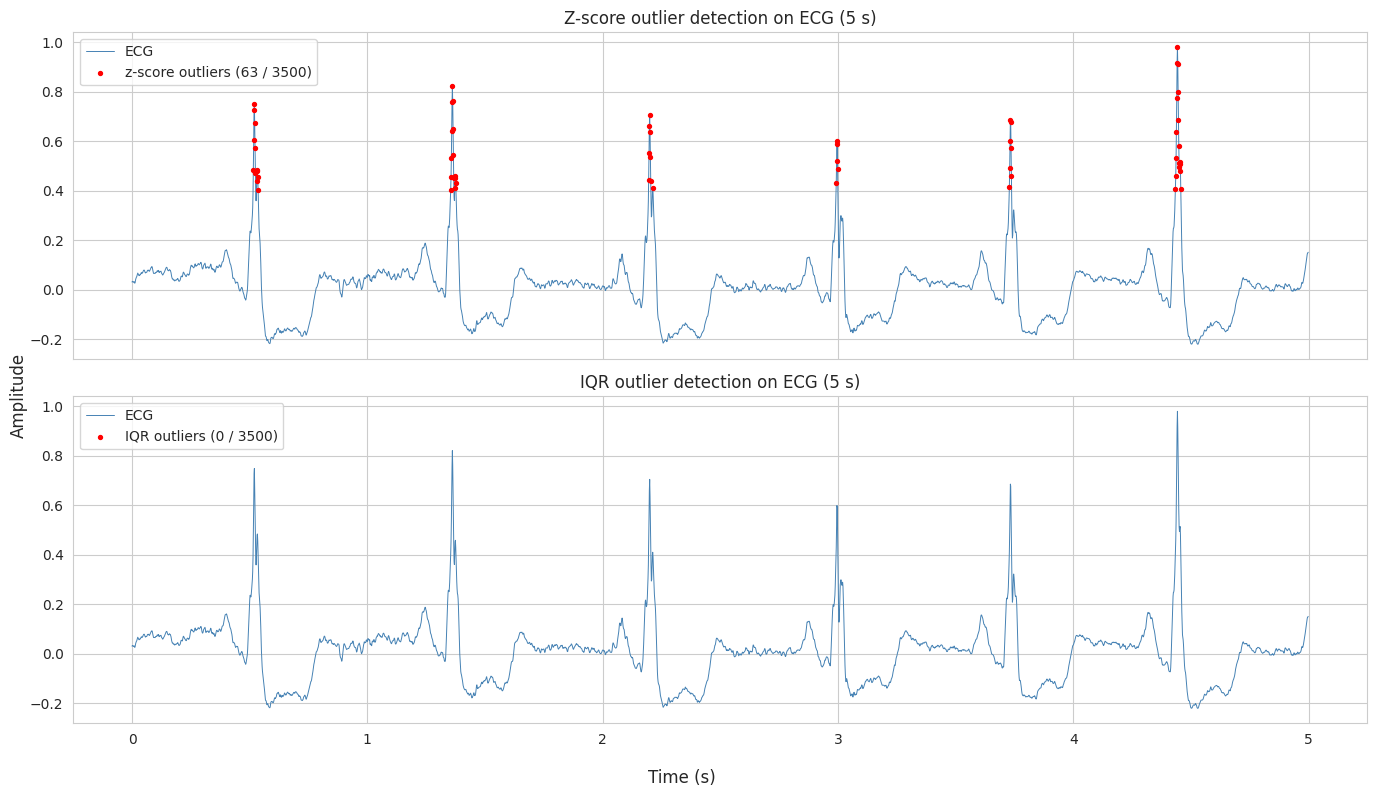

In [40]:
# ── Visualise WHAT the outlier detectors flag on ECG ──────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

seg = ecg_rest[:5*FS_CHEST]  # 5 seconds
t = np.arange(len(seg)) / FS_CHEST
mask_z = detect_outliers_zscore(seg, threshold=3.0)
mask_i = detect_outliers_iqr(seg, k=1.5)

# z-score
axes[0].plot(t, seg, lw=0.7, color='steelblue', label='ECG')
axes[0].scatter(t[mask_z], seg[mask_z], color='red', s=8, zorder=5,
                label=f'z-score outliers ({mask_z.sum()} / {len(seg)})')
axes[0].set_title('Z-score outlier detection on ECG (5 s)');  axes[0].legend()

# IQR
axes[1].plot(t, seg, lw=0.7, color='steelblue', label='ECG')
axes[1].scatter(t[mask_i], seg[mask_i], color='red', s=8, zorder=5,
                label=f'IQR outliers ({mask_i.sum()} / {len(seg)})')
axes[1].set_title('IQR outlier detection on ECG (5 s)');  axes[1].legend()

fig.supxlabel('Time (s)');  fig.supylabel('Amplitude')
plt.tight_layout();  plt.show()

⚠️  The red dots ARE the **R-peaks** — the most important part of the ECG! Global outlier detection treats normal physiological peaks as anomalies. Clamping or removing them would destroy the signal.

### 📝 Lesson Learned

**Global outlier detection (z-score / IQR applied to the entire signal) does NOT work for ECG** because:

1. **R-peaks are naturally extreme values** — they are the highest-amplitude events in a normal heartbeat cycle.
2. Removing or clamping them **destroys the most clinically relevant information** (heart rate, HRV, QRS morphology).
3. The same issue applies to other periodic physiological signals with sharp features (e.g., EMG bursts, skin conductance responses).

**When does global outlier detection make sense?**
- Slowly varying signals without sharp peaks (e.g., temperature, EDA tonic level)
- Tabular features (not raw time-series)

**What should we do instead?** → Detect **artifacts** (sensor noise, electrode detachment) using **windowed** analysis.

### 🧪 Simulating an Electrode Detachment Artifact

WESAD was recorded in controlled lab conditions, so the ECG is very clean. To **demonstrate** that windowed detection works, let's **inject a realistic artifact** into the signal.

**Electrode detachment** is one of the most common artifacts in ambulatory ECG:
- The electrode loses contact with the skin
- The signal drops to a **flat line** (or saturates at the ADC rail)
- Duration: typically 0.5–3 seconds

We inject a **1.5 s flat-line artifact** at a known position, then compare how global vs windowed detection handle it.

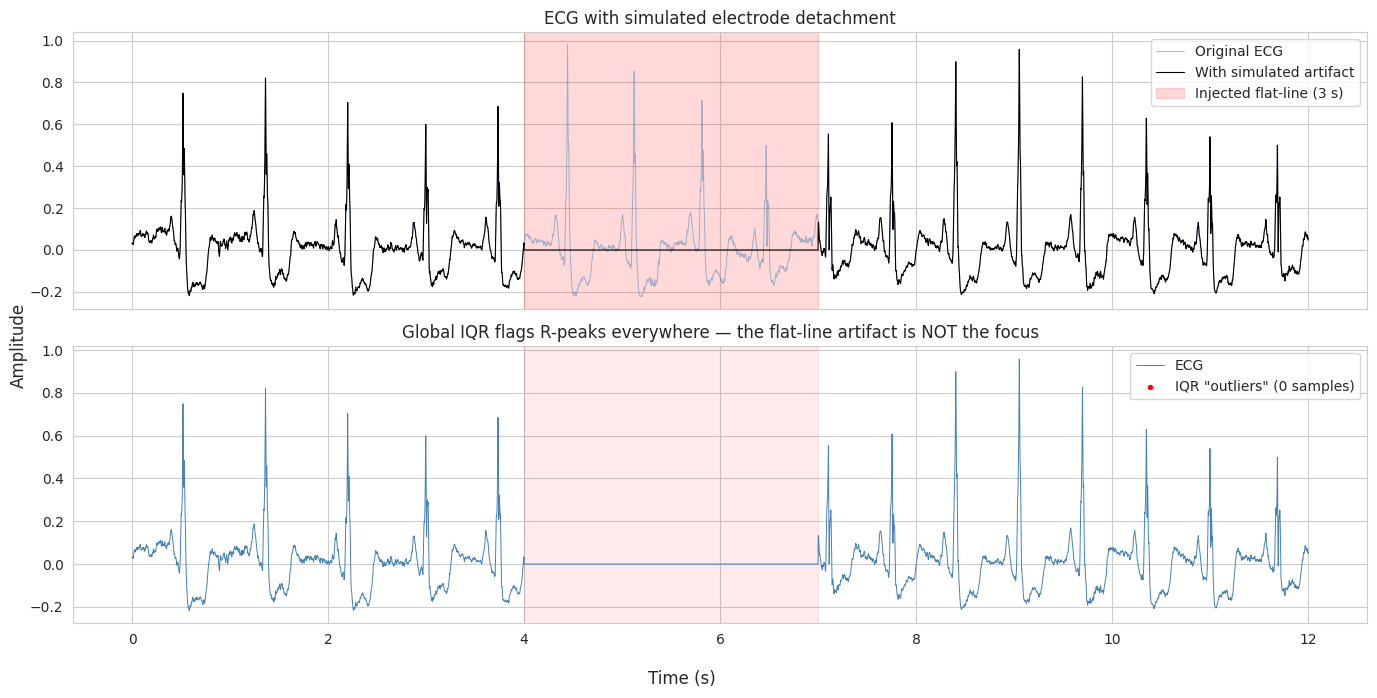


Global IQR flagged 0 samples total:
  • Inside artifact zone : 0
  • Outside (mostly R-peaks): 0  ← these are valid heart beats!

→ Global detection still obsesses over R-peaks and ignores the real problem.
  Next: windowed detection will focus on the actual artifact. ↓


In [41]:
# ── Simulate electrode detachment artifact ─────────────────────
# Take 12 s of clean ECG and inject a 3 s flat-line at t = 4 s
ecg_demo = ecg_rest[:12 * FS_CHEST].copy()
ecg_demo_original = ecg_demo.copy()  # keep pristine copy for comparison

artifact_start = int(4.0 * FS_CHEST)   # sample index at 4 s
artifact_end   = int(7.0 * FS_CHEST)   # sample index at 7 s  (3 s duration)
ecg_demo[artifact_start:artifact_end] = 0.0  # electrode off → flat-line

t_demo = np.arange(len(ecg_demo)) / FS_CHEST

# ── Visualise: clean vs corrupted signal + global IQR ──────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Panel 1 – original vs corrupted
axes[0].plot(t_demo, ecg_demo_original, lw=0.7, color='steelblue', alpha=0.5, label='Original ECG')
axes[0].plot(t_demo, ecg_demo, lw=0.8, color='black', label='With simulated artifact')
axes[0].axvspan(4.0, 7.0, color='red', alpha=0.15, label='Injected flat-line (3 s)')
axes[0].set_title('ECG with simulated electrode detachment')
axes[0].legend()

# Panel 2 – global IQR on the corrupted signal
mask_iqr_demo = detect_outliers_iqr(ecg_demo, k=1.5)
axes[1].plot(t_demo, ecg_demo, lw=0.7, color='steelblue', label='ECG')
axes[1].scatter(t_demo[mask_iqr_demo], ecg_demo[mask_iqr_demo], color='red', s=8,
                zorder=5, label=f'IQR "outliers" ({mask_iqr_demo.sum()} samples)')
axes[1].axvspan(4.0, 7.0, color='red', alpha=0.08)
axes[1].set_title('Global IQR flags R-peaks everywhere — the flat-line artifact is NOT the focus')
axes[1].legend()

fig.supxlabel('Time (s)');  fig.supylabel('Amplitude')
plt.tight_layout();  plt.show()

n_iqr_in_art = mask_iqr_demo[artifact_start:artifact_end].sum()
n_iqr_outside = mask_iqr_demo.sum() - n_iqr_in_art
print(f'\nGlobal IQR flagged {mask_iqr_demo.sum()} samples total:')
print(f'  • Inside artifact zone : {n_iqr_in_art}')
print(f'  • Outside (mostly R-peaks): {n_iqr_outside}  ← these are valid heart beats!')
print('\n→ Global detection still obsesses over R-peaks and ignores the real problem.')
print('  Next: windowed detection will focus on the actual artifact. ↓')

### Windowed Artifact Detection 

Instead of flagging individual extreme samples, we analyse **short windows** and look for patterns that indicate **sensor artifacts** (not physiological events):

- **Electrode detachment** → signal saturates (flat line) or has extreme amplitude for an extended period
- **Motion artifact** → sudden broadband noise burst
- **Loose electrode** → abnormally high variance in a short window

The idea: in a small window (e.g., 1–2 seconds), an R-peak is a *normal* event. But a large chunk of samples with
extreme values or flat signal indicates a *real* artifact.

In [43]:
def detect_artifacts_windowed(signal, fs, window_sec=1.0, zscore_thresh=5.0,
                              flat_thresh=1e-4):
    """Detect artifact windows in a physiological signal.

    A window is flagged as artifact if:
    - More than 50% of samples exceed zscore_thresh (global z-score), OR
    - The window std is below flat_thresh (flat-line / saturation)

    Parameters
    ----------
    signal : np.ndarray
    fs : int (sampling rate)
    window_sec : float (window length in seconds)
    zscore_thresh : float (threshold for z-score — higher than normal since
                   we want to catch only truly extreme extended artifacts)
    flat_thresh : float (std threshold to detect flat-line)

    Returns
    -------
    artifact_mask : np.ndarray[bool] (True = artifact sample)
    """
    w = int(window_sec * fs)
    z = np.abs((signal - np.mean(signal)) / np.std(signal))
    artifact_mask = np.zeros(len(signal), dtype=bool)

    for start in range(0, len(signal) - w + 1, w):
        end = start + w
        window = signal[start:end]
        z_window = z[start:end]

        frac_extreme = np.mean(z_window > zscore_thresh)
        is_flat = np.std(window) < flat_thresh
        if frac_extreme > 0.5 or is_flat:
            artifact_mask[start:end] = True

    return artifact_mask

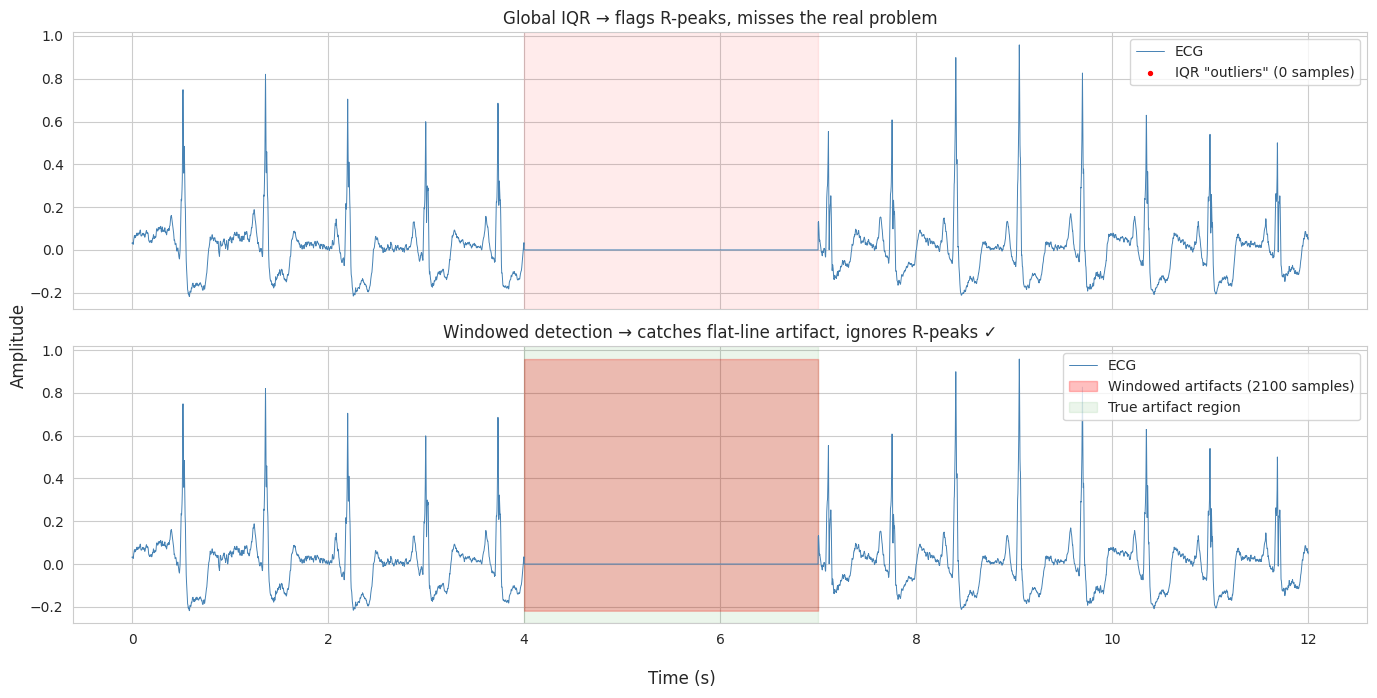


Method                    Inside artifact    Outside (R-peaks)   
───────────────────────── ────────────────── ────────────────────
Global IQR                0                  0                    ← flags heart beats!
Windowed                  2100               0                    ← clean ✓

✓ Windowed detection finds the electrode detachment while preserving R-peaks.

Applying windowed artifact detection to real WESAD data...

=== Windowed artifact detection (real data) ===
  Rest: 0 artifact samples (0.00%)
  Stress: 0 artifact samples (0.00%)
  Amusement: 0 artifact samples (0.00%)

✓ TODO 3 passed


In [44]:
 #══════════════════════════════════════════════════════════════
# PART A — Windowed detection on the SIMULATED artifact signal
# ══════════════════════════════════════════════════════════════
art_demo = detect_artifacts_windowed(ecg_demo, FS_CHEST)

# ── Side-by-side comparison: global IQR vs windowed on corrupted signal ──
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Global IQR (already computed above as mask_iqr_demo)
axes[0].plot(t_demo, ecg_demo, lw=0.7, color='steelblue', label='ECG')
axes[0].scatter(t_demo[mask_iqr_demo], ecg_demo[mask_iqr_demo],
                color='red', s=8, zorder=5,
                label=f'IQR "outliers" ({mask_iqr_demo.sum()} samples)')
axes[0].axvspan(4.0, 7.0, color='red', alpha=0.08)
axes[0].set_title('Global IQR → flags R-peaks, misses the real problem')
axes[0].legend()

# Windowed detection
axes[1].plot(t_demo, ecg_demo, lw=0.7, color='steelblue', label='ECG')
axes[1].fill_between(t_demo, ecg_demo.min(), ecg_demo.max(),
                     where=art_demo[:len(t_demo)], color='red', alpha=0.25,
                     label=f'Windowed artifacts ({art_demo.sum()} samples)')
axes[1].axvspan(4.0, 7.0, color='green', alpha=0.08, label='True artifact region')
axes[1].set_title('Windowed detection → catches flat-line artifact, ignores R-peaks ✓')
axes[1].legend()

fig.supxlabel('Time (s)');  fig.supylabel('Amplitude')
plt.tight_layout();  plt.show()

# ── Summary table ──────────────────────────────────────────────
n_iqr_in  = mask_iqr_demo[artifact_start:artifact_end].sum()
n_iqr_out = mask_iqr_demo.sum() - n_iqr_in
n_win_in  = art_demo[artifact_start:artifact_end].sum()
n_win_out = art_demo.sum() - n_win_in

print(f'\n{"Method":<25} {"Inside artifact":<18} {"Outside (R-peaks)":<20}')
print(f'{"─"*25} {"─"*18} {"─"*20}')
print(f'{"Global IQR":<25} {n_iqr_in:<18} {n_iqr_out:<20} ← flags heart beats!')
print(f'{"Windowed":<25} {n_win_in:<18} {n_win_out:<20} ← clean ✓')
print('\n✓ Windowed detection finds the electrode detachment while preserving R-peaks.')

# ══════════════════════════════════════════════════════════════
# PART B — Apply windowed detection to REAL data for cleaning
# ══════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('Applying windowed artifact detection to real WESAD data...')
print('='*60)

art_rest   = detect_artifacts_windowed(ecg_rest,   FS_CHEST)
art_stress = detect_artifacts_windowed(ecg_stress, FS_CHEST)
art_amuse  = detect_artifacts_windowed(ecg_amuse,  FS_CHEST)

print('\n=== Windowed artifact detection (real data) ===')
for name, sig, mask in [('Rest', ecg_rest, art_rest),
                        ('Stress', ecg_stress, art_stress),
                        ('Amusement', ecg_amuse, art_amuse)]:
    n_art = mask.sum()
    print(f'  {name}: {n_art} artifact samples ({n_art/len(sig)*100:.2f}%)')

# Clean ECG: replace artifact windows with interpolation, keep R-peaks intact
ecg_rest_clean   = clamp_outliers(ecg_rest,   art_rest)   if art_rest.any()   else ecg_rest.copy()
ecg_stress_clean = clamp_outliers(ecg_stress, art_stress) if art_stress.any() else ecg_stress.copy()
ecg_amuse_clean  = clamp_outliers(ecg_amuse,  art_amuse)  if art_amuse.any()  else ecg_amuse.copy()

# Checkpoint
assert detect_outliers_zscore(ecg_rest, 3.0).dtype == bool
assert len(detect_outliers_iqr(ecg_rest)) == len(ecg_rest)
print('\n✓ TODO 3 passed')

### 🤔 Reflection

1. **What happens if you change the window size for detecting the artifact?**
2. **Would interpolation solve a long detachment artifact?** What strategy would you follow to handle those invalid values?
3. **Why does windowed artifact detection preserve R-peaks?** Think about what is "normal" within a short window vs the entire signal.
4. **WESAD is a controlled lab study with clean data. In what real-world scenarios would you expect more artifacts?** 
5. **Would global outlier detection be appropriate for EDA (electrodermal activity)?** Why or why not?

*Your answers:*

1. If the window is too small (e.g., 0.1s): The detector might mistake a single R-peak or a brief pause for an artifact. It loses "context."

If the window is too large (e.g., 10s): A short 1-second artifact might get "diluted" by the 9 seconds of good data. The average std or z-score for the whole 10 seconds might look "normal," allowing the artifact to slip through undetected.

Optimal: The window should be roughly the same size as the expected artifact (usually 1–2 seconds for electrode issues).


2. Answer: No. Interpolation only "works" by guessing a straight line between two points. If you have a 30-second gap, a straight line is medically meaningless and dangerous to analyze.

Strategy: * Data Exclusion: Mark that segment as "Invalid" and exclude it from the final AI analysis.

Segmented Analysis: Only calculate features (like Heart Rate) for the clean chunks and ignore the gaps.

Rejection: If a patient has more than, say, 20% total artifact time, discard that patient’s entire session.


3. Answer: Because an R-peak is a local event, not a global failure.

4. Ambulatory Monitoring: Patients walking, running, or sleeping while wearing sensors (leads to "Motion Artifacts").

Chronic Use: Wearables like Apple Watches or Fitbits where the sensor might shift due to sweat or loose straps.

5. Answer: Yes, it is much more appropriate for EDA than for ECG.

Why: Unlike the ECG, which has rapid, "outlier-looking" R-peaks every second, EDA is a slowly varying signal. It doesn't have sharp periodic spikes that are medically necessary. A massive spike in EDA is almost always a "noise" artifact (like someone tapping the sensor), so a global Z-score or IQR can catch those spikes without deleting critical "heartbeat-like" information.

---
## Section 3 — Filtering

⏱ **Estimated time: 15 min** · TODO 4

> **From lecture 2.3:** Filters remove unwanted frequency components due to interferences or related to spectral components that we are not interested in analyse.

First, look at the PSD of the ECG signal running the code below.

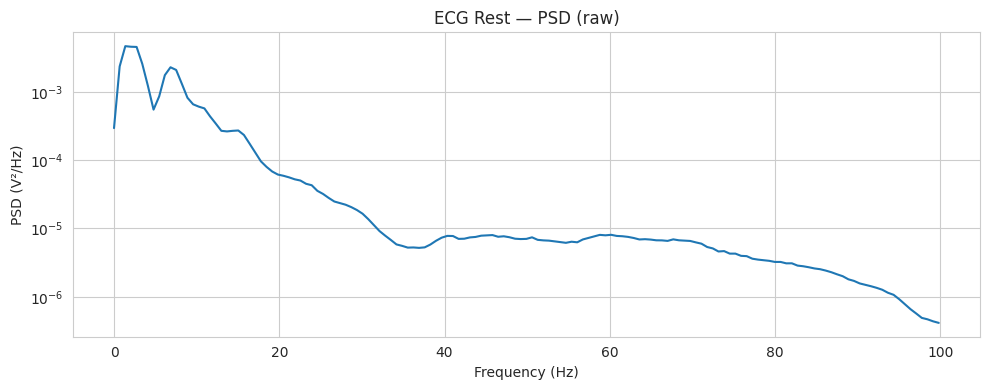

Physiological ECG: 0.5–40 Hz. Below: baseline wander. Above: noise.


In [45]:
# ── PSD of raw ECG (provided) ──────────────────────────────────
plot_psd(ecg_rest_clean, FS_CHEST, title='ECG Rest — PSD (raw)', max_freq=100)
print("Physiological ECG: 0.5–40 Hz. Below: baseline wander. Above: noise.")


### TODO 4 — Butterworth Filters (~12 min)

Implement two methods to apply **bandpass** and **lowpass filtering** on an input signal. The *scipy* package provides many useful functions that implement signal processing operations such as filtering.

<details><summary><b>Hint </b></summary>
Look for the butter() and the filtfilt() methods of scipy package!
</details>



In [57]:
from scipy.signal import butter, filtfilt

def apply_bandpass_filter(signal, lowcut, highcut, fs, order=4):
    # ── TODO 4a ─────────────────────────────────
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    
    # Create the filter coefficients (b, a)
    b, a = butter(order, [low, high], btype='band')
    
    # Apply the filter forwards and backwards to avoid phase shift
    return filtfilt(b, a, signal)
    

def apply_lowpass_filter(signal, highcut, fs, order=4):
    # ── TODO 4b ─────────────────────────────────
    nyquist = 0.5 * fs
    high = highcut / nyquist

    b, a = butter(order, high, btype ='low')

    return filtfilt(b, a, signal)
    


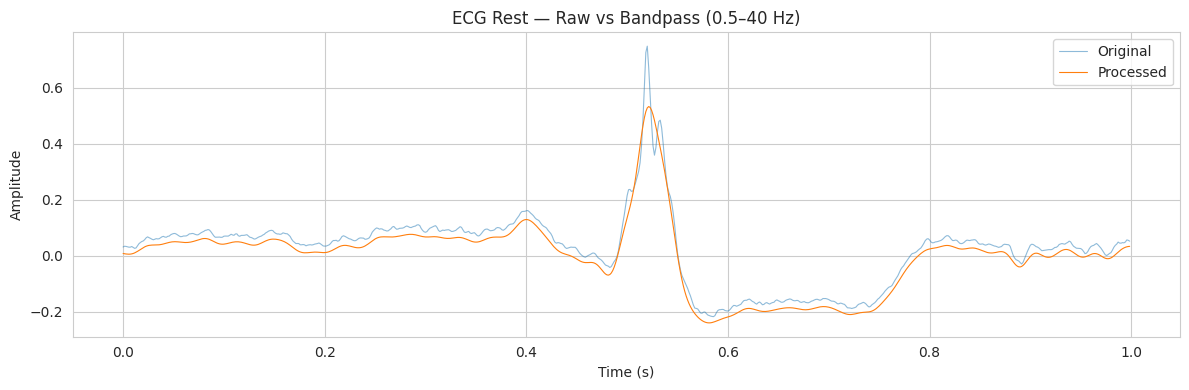

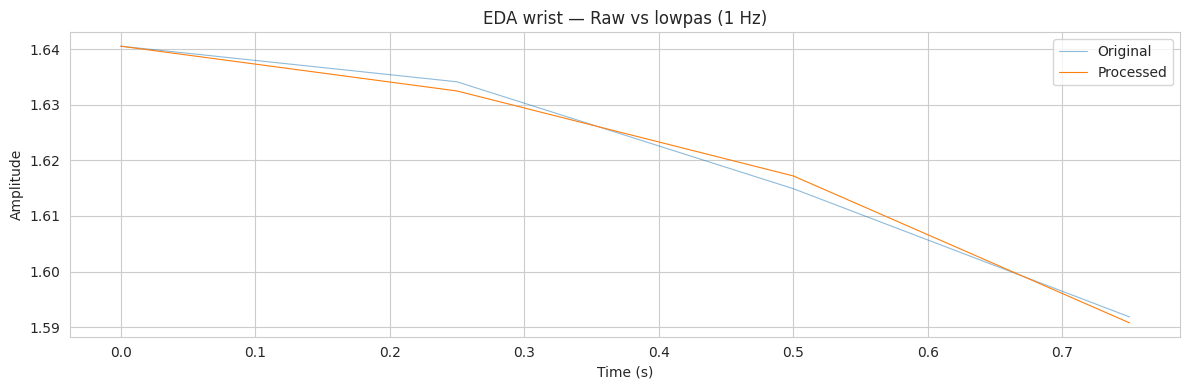

In [59]:
# ── Apply and verify ───────────────────────────────────────────
ecg_rest_filt   = apply_bandpass_filter(ecg_rest_clean,   0.5, 40, FS_CHEST)
ecg_stress_filt = apply_bandpass_filter(ecg_stress_clean, 0.5, 40, FS_CHEST)
ecg_amuse_filt  = apply_bandpass_filter(ecg_amuse_clean,  0.5, 40, FS_CHEST)

plot_comparison(ecg_rest_clean, ecg_rest_filt, FS_CHEST,
                title='ECG Rest — Raw vs Bandpass (0.5–40 Hz)', seconds=1)

# EDA wrist lowpass
eda_wrist_rest_filt   = apply_lowpass_filter(eda_wrist_rest,   1.0, FS_WRIST_EDA)
eda_wrist_stress_filt = apply_lowpass_filter(eda_wrist_stress, 1.0, FS_WRIST_EDA)
eda_wrist_amuse_filt  = apply_lowpass_filter(eda_wrist_amuse,  1.0, FS_WRIST_EDA)

plot_comparison(eda_wrist_rest, eda_wrist_rest_filt, FS_WRIST_EDA,
                title='EDA wrist — Raw vs lowpas (1 Hz)', seconds=1)


**Neurokit v2 version.** 

You can also achieve the same result using the neurokit package.

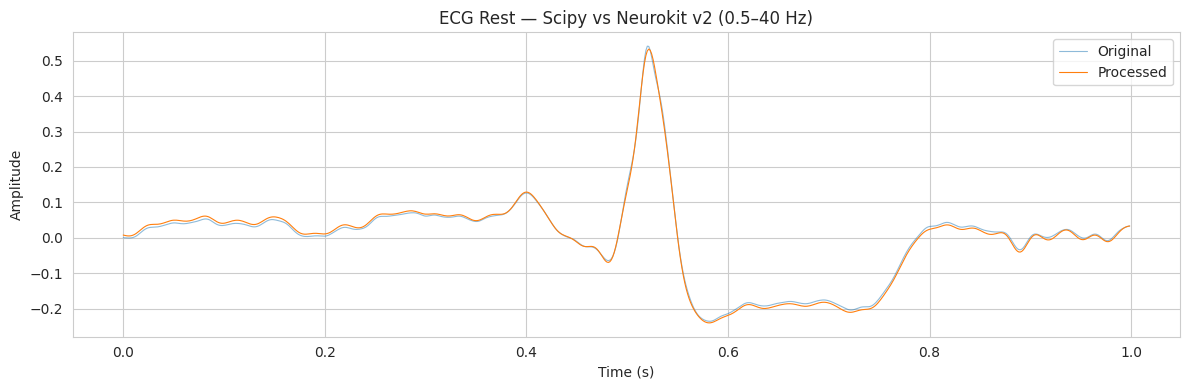

Correlation with neurokit2: 0.999722
✓ TODO 4 passed


In [60]:
# Checkpoint: compare with neurokit2
ecg_nk = nk.signal_filter(ecg_rest_clean, lowcut=0.5, highcut=40, sampling_rate=FS_CHEST)
corr = np.corrcoef(ecg_rest_filt, ecg_nk)[0, 1]
plot_comparison(ecg_nk, ecg_rest_filt, FS_CHEST,
                title='ECG Rest — Scipy vs Neurokit v2 (0.5–40 Hz)', seconds=1)


print(f"Correlation with neurokit2: {corr:.6f}")
assert corr > 0.95, f"Too low ({corr:.4f})"
print("✓ TODO 4 passed")

---
## Section 4 — Resampling

⏱ **Estimated time: 12 min** · TODO 5

Resampling is necessary:
* to extrapolate a uniform and coherent temporal representation across signals recorded at different time scales for data fusion
* remove high frequency noise by undersampling
* increase computational efficiency, as higher fps implies larger memory usage and higher power comsumption.

As an example, implement the resampling of all wrist signals to **64 Hz** (BVP rate) for a common time axis.

<details><summary><b>Hint</b></summary>
`n_new = int(len(signal) * fs_target / fs_orig)` → `scipy.signal.resample(signal, n_new)`
</details>


In [61]:
from scipy.signal import resample

def resample_signal(signal, fs_orig, fs_target):
    # ── TODO 5 ──────────────────────────────────
    # 1. Calculate how many samples the signal should have at the new rate
    n_samples_new = int(len(signal) * fs_target / fs_orig)
    
    # 2. Use Fourier-method resampling to compute the new values
    resampled_sig = resample(signal, n_samples_new)
    return resampled_sig


In [62]:
# ── Apply ──────────────────────────────────────────────────────
eda_wrist_rest_rs   = resample_signal(eda_wrist_rest_filt,   FS_WRIST_EDA, FS_TARGET)
eda_wrist_stress_rs = resample_signal(eda_wrist_stress_filt, FS_WRIST_EDA, FS_TARGET)
eda_wrist_amuse_rs  = resample_signal(eda_wrist_amuse_filt,  FS_WRIST_EDA, FS_TARGET)

acc_rest_rs   = resample_signal(acc_rest,   FS_WRIST_ACC, FS_TARGET)
acc_stress_rs = resample_signal(acc_stress, FS_WRIST_ACC, FS_TARGET)
acc_amuse_rs  = resample_signal(acc_amuse,  FS_WRIST_ACC, FS_TARGET)

bvp_rest_rs   = bvp_rest.copy()
bvp_stress_rs = bvp_stress.copy()
bvp_amuse_rs  = bvp_amuse.copy()

for name, orig, rs, fs_o in [
    ('EDA wrist', eda_wrist_rest_filt, eda_wrist_rest_rs, FS_WRIST_EDA),
    ('ACC wrist', acc_rest,            acc_rest_rs,        FS_WRIST_ACC)]:
    exp = int(len(orig) * FS_TARGET / fs_o)
    print(f"{name}: {len(orig)} @ {fs_o} Hz → {len(rs)} @ {FS_TARGET} Hz (expected ~{exp})")
    assert abs(len(rs) - exp) <= 1
print("✓ TODO 5 passed")


EDA wrist: 1200 @ 4 Hz → 19200 @ 64 Hz (expected ~19200)
ACC wrist: 9600 @ 32 Hz → 19200 @ 64 Hz (expected ~19200)
✓ TODO 5 passed


---
## Section 5 — Normalisation

Data normalization is an important step, especially when you have to:
* Align the representation across features with very different scales, as many machine learning models are based on measuring separation between classes/clusters according to distance-based metrics (more in the next Lab!)
* Remove subject-dependent characteristics, as baseline values of many physiological signals depends on specific characteristics of each individual. For instance, a pro athlete 🚴 in thriatlon running will have a resting mean beat per minute that is much lower than the one of a 80 years old granny! 👵🏻 

⏱ **Estimated time: 10 min** · TODO 6

<details><summary><b>Hint</b></summary>
Z-score: `(sig - mean) / std` · Min-max: `(sig - min) / (max - min)`
</details>


In [64]:
def normalize_zscore(signal):
    # ── TODO 6a ─────────────────────────────────
    mu = np.nanmean(signal)
    std = np.nanstd(signal)

    if std == 0:
        return -mu

    return (signal - mu) /std 


def normalize_minmax(signal):
    # ── TODO 6b ─────────────────────────────────
    mmax = np.nanmax(signal)
    mmin = np.nanmin(signal)

    if mmin == mmax: 
        return np.zeros_like(signal)

    return (signal - mmin)/(mmax - mmin)


In [65]:
for name, sig in [('ECG', ecg_rest_filt[:5*FS_CHEST]),
                  ('EDA', eda_wrist_rest_rs[:5*FS_TARGET]),
                  ('ACC', acc_rest_rs[:5*FS_TARGET])]:
    z = normalize_zscore(sig);  m = normalize_minmax(sig)
    print(f"{name}:  z-score → mean={np.mean(z):.6f} std={np.std(z):.6f}  |  "
          f"min-max → min={np.min(m):.4f} max={np.max(m):.4f}")

ecg_z = normalize_zscore(ecg_rest_filt[:5*FS_CHEST])
ecg_m = normalize_minmax(ecg_rest_filt[:5*FS_CHEST])
assert abs(np.mean(ecg_z)) < 1e-6 and abs(np.std(ecg_z)-1) < 1e-6
assert np.min(ecg_m) >= -1e-10 and np.max(ecg_m) <= 1+1e-10
print("✓ TODO 6 passed")


ECG:  z-score → mean=0.000000 std=1.000000  |  min-max → min=0.0000 max=1.0000
EDA:  z-score → mean=0.000000 std=1.000000  |  min-max → min=0.0000 max=1.0000
ACC:  z-score → mean=-0.000000 std=1.000000  |  min-max → min=0.0000 max=1.0000
✓ TODO 6 passed


---
## Section 6 — Segmentation

Segmentation is useful when you need to:
* Increase the number of samples available to train your model
* Increase the granularity at which you want to observe a certain phenomenon, for instance moving from a scale of minutes to a scale of few seconds
* Reduce dimension of data that your model has to process inputs, thus model complexity (e.g., less input weigths for neural networks)

Implement signal segmentation using the formula below.

⏱ **Estimated time: 12 min** · TODO 7

$$n_{\text{segments}} = \left\lfloor \frac{L - W}{S} \right\rfloor + 1 \quad \text{where } S = W \times (1 - \text{overlap})$$

<details><summary><b>Hint</b></summary>
`step = int(window_samples * (1 - overlap))` → `for start in range(0, len(signal) - window_samples + 1, step)`
</details>


In [79]:
def segment_signal(signal, window_samples, overlap=0.5):
    # ── TODO 7 ──────────────────────────────────
    assert 0 <= overlap < 1
    segments = []
    step = int(window_samples * (1 - overlap))

    for start in range (0, len(signal) - int(window_samples) +1, step ):
        end = start + window_samples
        segments.append(signal[start: end]) 
    return segments


In [80]:
w_ecg = WINDOW_SEC * FS_CHEST;  w_wrist = WINDOW_SEC * FS_TARGET
segs_test = segment_signal(ecg_rest_filt, w_ecg, OVERLAP)
step = int(w_ecg * (1 - OVERLAP))
expected = (len(ecg_rest_filt) - w_ecg) // step + 1
print(f"ECG rest: {len(segs_test)} segments (expected {expected})")
assert len(segs_test) == expected and all(len(s)==w_ecg for s in segs_test)
print("✓ TODO 7 passed")


ECG rest: 9 segments (expected 9)
✓ TODO 7 passed


---
## Section 7 — Feature Extraction

⏱ **Estimated time: 40 min** · TODOs 8–10 + provided domain features

> **From lecture 2.5:** Feature extraction transforms raw segments into descriptive variables.

In this section you will:
1. Implement **statistical** time-domain and frequency-domain features (TODOs 8–10)
3. Explore **neurokit2** and implement **domain-specific** physiological feature extractors for ECG/HRV and EDA

**Generic features per segment:**

| Domain | Feature | Formula / tool |
|--------|---------|----------------|
| Time | mean, std, rms, min, max, iqr, skewness, kurtosis, peak-to-peak | numpy / scipy.stats |
| Freq | dominant_freq, total_power, spectral_entropy | `scipy.signal.welch` |

**Domain-specific features (added via neurokit2):**

| Signal | Features | Tool |
|--------|----------|------|
| ECG | HR mean/std, R-peak count | `nk.ecg_process` |
| HRV | RMSSD, SDNN, pNN50, MeanNN, LF, HF, LF/HF | `nk.hrv_time`, `nk.hrv_frequency` |
| EDA | Tonic mean/std, Phasic mean/std/max, SCR count, SCR amplitude | `nk.eda_process` |


### TODO 8 — Time-Domain Features (~10 min)

Time-domain features describe the **statistical shape** of a signal segment — central tendency, variability, symmetry and extremes. They are **signal-agnostic**: the same set works for ECG, EDA, BVP or accelerometer. You can compute this quantities using *numpy* and *scipy* functions.

For each segment, compute these 9 descriptors:


|Feature|What it captures|
|---------|------------------|
| `mean` | DC offset / baseline level |
| `std` | Signal variability |
| `rms` | Signal energy (root-mean-square) |
| `min`, `max`, `peak_to_peak` | Dynamic range |
| `kurtosis` | Tail weight — peaky vs flat distribution |
| `iqr` | Robust spread (less sensitive to outliers than std) |
| `skewness` | Asymmetry of amplitude distribution |


In [87]:
from scipy import stats

def extract_time_features(segment):
    """Return dict with keys: mean, std, rms, min, max, iqr, skewness, kurtosis, peak_to_peak"""
    # ── TODO 8 ──────────────────────────────────
    features = {
        'mean' : np.nanmean(segment),
        'std' : np.nanstd(segment),
        'rms': np.sqrt(np.mean(segment**2)),
        'min' : np.nanmin(segment),
        'max': np.nanmax(segment),
        'iqr': stats.iqr(segment),
        'skewness': stats.skew(segment),
        'kurtosis': stats.kurtosis(segment),
        'peak_to_peak': np.ptp(segment)
    }
    # ────────────────────────────────────────────
    return features


### TODO 9 — Frequency-Domain Features (~10 min)

Frequency-domain features reveal **which frequencies carry the signal's energy**. Use `scipy.signal.welch` to estimate the Power Spectral Density (PSD), then extract three summary statistics:

| Feature | What it captures |
|---------|------------------|
| `dominant_freq` | Frequency (Hz) with the highest power — e.g. heart rate for ECG |
| `total_power` | Integral of PSD — overall signal energy in the segment |
| `spectral_entropy` | How *spread out* the spectrum is: high → broadband/noisy, low → peaked/periodic |

A resting ECG has a clear spectral peak (the heart rate), while a stressed ECG shifts frequency profile. EDA and BVP also exhibit spectral changes with arousal.


<details><summary><b>Hint 1- PSD computation </b></summary>

`freqs, psd = welch(segment, fs=fs, nperseg=min(256, len(segment)))`</details>

<details><summary><b>Hint 2 - Dominant frequency </b></summary>
    
 `dominant_freq = freqs[np.argmax(psd)]` · `total_power = np.trapz(psd, freqs)`</details>

    
<details><summary><b><b>Hint 3</b> — Spectral entropy</summary>

`psd_n = psd / (psd.sum()+1e-12);  entropy = -np.sum(psd_n * np.log2(psd_n + 1e-12))`</details>


In [83]:
from scipy.signal import welch

def extract_freq_features(segment, fs):
    """Return dict with keys: dominant_freq, total_power, spectral_entropy"""
    freqs, psd = welch(segment, fs=fs, nperseg=min(256, len(segment)))
    # ── TODO 9 ──────────────────────────────────
    # 1. Which frequency is the strongest? (Highest peak)
    dominant_freq = freqs[np.argmax(psd)]
    
    # 2. Area under the curve (Total Energy)
    total_power = np.trapz(psd, freqs)
    
    # 3. Spectral Entropy (How 'flat' or 'peaky' the spectrum is)
    # Normalize PSD so it sums to 1 (like a probability distribution)
    psd_n = psd / (psd.sum() + 1e-12)
    # Apply the Shannon entropy formula
    spectral_entropy = -np.sum(psd_n * np.log2(psd_n + 1e-12))
    
    features = {
        'dominant_freq' : dominant_freq,
        'total_power' : total_power,
        'spectral_entropy': spectral_entropy 
    }
    # ────────────────────────────────────────────
    return features


### TODO 10 — Build the Feature Matrix (~10 min)

Before moving to domain-specific features, let's assemble statistical feature in a comprehensive feature matrix.

The function you have to implement should:
1. Iterate over each signal name and its list of segments
2. For each segment, call `extract_time_features` and `extract_freq_features`
3. Prefix each feature key with the signal name (e.g. `ECG_mean`, `EDA_std`)
4. Add `subject_id` and `label` columns
5. Return a DataFrame with **one row per segment**

<details><summary><b>Hint</b></summary>

```python
for sig_name, segs in segments_dict.items():
    for seg in segs:
        tf = extract_time_features(seg)
        ff = extract_freq_features(seg, fs_dict[sig_name])
        for k, v in tf.items():
            row[f'{sig_name}_{k}'] = v
        ...
```
</details>


In [85]:
def build_feature_dataframe(segments_dict, fs_dict, label, subject_id):
    """Build a DataFrame: one row per segment, columns = features + metadata.

    Parameters
    ----------
    segments_dict : dict[str, list[np.ndarray]]
        e.g. {'ECG': [seg1, seg2, ...], 'EDA': [...], ...}
    fs_dict : dict[str, int]
        e.g. {'ECG': 700, 'EDA': 64, ...}
    label : int
    subject_id : str

    Returns
    -------
    pd.DataFrame
    """
    # ── TODO 10 ─────────────────────────────────
    # For each segment index:
    #   for each signal name:
    #     extract time features (prefix with signal name)
    #     extract freq features (prefix with signal name)
    #   add subject_id, label
    #   append row
    # ────────────────────────────────────────────
    rows = []
    
    first_sig = list(segments_dict.keys())[0]
    num_segments = len(segments_dict[first_sig])
    
    for i in range(num_segments):
        row = {
            'subject_id': subject_id,
            'label': label
        }
        
        # Extract features for every signal at this specific segment index
        for sig_name, seg_list in segments_dict.items():
            segment = seg_list[i]
            fs = fs_dict[sig_name]
            
            # 1. Get stats
            tf = extract_time_features(segment)
            ff = extract_freq_features(segment, fs)
            
            # 2. Add prefixed time features to the row
            for k, v in tf.items():
                row[f'{sig_name}_{k}'] = v
                
            # 3. Add prefixed frequency features to the row
            for k, v in ff.items():
                row[f'{sig_name}_{k}'] = v
        
        rows.append(row)
        
    return pd.DataFrame(rows)


In [88]:
# ── Build feature matrix for S2 (Rest + Stress) ───────────────
fs_map = {'ECG': FS_CHEST, 'EDA': FS_TARGET, 'BVP': FS_TARGET, 'ACC': FS_TARGET}

segs_rest = {
    'ECG': segment_signal(ecg_rest_filt,     WINDOW_SEC*FS_CHEST,  OVERLAP),
    'EDA': segment_signal(eda_wrist_rest_rs, WINDOW_SEC*FS_TARGET, OVERLAP),
    'BVP': segment_signal(bvp_rest_rs,       WINDOW_SEC*FS_TARGET, OVERLAP),
    'ACC': segment_signal(acc_rest_rs,        WINDOW_SEC*FS_TARGET, OVERLAP),
}
segs_stress = {
    'ECG': segment_signal(ecg_stress_filt,      WINDOW_SEC*FS_CHEST,  OVERLAP),
    'EDA': segment_signal(eda_wrist_stress_rs,  WINDOW_SEC*FS_TARGET, OVERLAP),
    'BVP': segment_signal(bvp_stress_rs,        WINDOW_SEC*FS_TARGET, OVERLAP),
    'ACC': segment_signal(acc_stress_rs,         WINDOW_SEC*FS_TARGET, OVERLAP),
}

df_rest   = build_feature_dataframe(segs_rest,   fs_map, label=0, subject_id='S2')
df_stress = build_feature_dataframe(segs_stress, fs_map, label=1, subject_id='S2')
df_features = pd.concat([df_rest, df_stress], ignore_index=True)

feat_cols = [c for c in df_features.columns if c not in ['subject_id','label']]
print(f"Feature matrix: {df_features.shape}  ({len(feat_cols)} features)")
display(df_features.head())

assert len(feat_cols) > 0, "No feature columns — check TODO 10"
assert df_features[feat_cols].isna().sum().sum() == 0, "Contains NaN"
print("✓ TODOs 8–10 passed")


Feature matrix: (18, 50)  (48 features)


,subject_id,label,ECG_mean,ECG_std,ECG_rms,ECG_min,ECG_max,ECG_iqr,ECG_skewness,ECG_kurtosis,...,ACC_rms,ACC_min,ACC_max,ACC_iqr,ACC_skewness,ACC_kurtosis,ACC_peak_to_peak,ACC_dominant_freq,ACC_total_power,ACC_spectral_entropy
0,S2,0,0.000260,0.136938,0.136938,-0.363687,0.780815,0.151885,1.180938,4.229073,...,63.921066,19.467134,140.659530,2.585466,1.788979,19.466673,121.192396,1.25,35.845119,5.645022
1,S2,0,-0.000124,0.148655,0.148655,-0.341727,0.774069,0.173904,1.026468,3.731255,...,63.481906,33.674916,109.164316,1.402259,1.599060,22.925336,75.489399,2.25,11.706697,5.597720
2,S2,0,-0.000024,0.152718,0.152718,-0.292599,0.799540,0.169905,0.964691,3.810468,...,63.378580,33.674916,82.103593,1.185758,-0.944746,24.293681,48.428677,0.75,5.545660,5.568285
3,S2,0,-0.000106,0.181671,0.181671,-1.495617,1.449932,0.163770,-0.083814,14.805380,...,63.488433,53.721504,75.000000,0.708586,0.419146,15.018420,21.278496,1.75,1.835770,5.508312
4,S2,0,-0.000184,0.181874,0.181874,-1.495617,1.449932,0.194433,-0.141465,14.329442,...,64.000420,30.668137,110.715853,0.901506,2.374421,20.763691,80.047716,1.00,24.735980,5.571479


✓ TODOs 8–10 passed


### 7b — Domain-Specific Physiological Features (neurokit2)

The time-domain and frequency-domain features you computed above are **generic signal descriptors** — useful for any time-series.
However, physiological signals have well-studied structure that allows us to compute **domain-specific features** that are far more interpretable and often more discriminative.

| Signal | Domain features | Why they matter |
|--------|----------------|-----------------|
| ECG | R-peak locations, heart rate (HR) | Direct measure of cardiac activity |
| ECG → HRV | RMSSD, SDNN, pNN50, LF/HF ratio | Heart rate *variability* reflects autonomic nervous system balance (sympathetic vs parasympathetic) |
| EDA | Tonic (SCL) vs Phasic (SCR) decomposition, SCR count, SCR amplitude | Separates slow baseline (tonic) from rapid responses (phasic) to stimuli |

We use [**neurokit2**](https://neuropsychology.github.io/NeuroKit/) to compute them. Consult the documentation to understand the functions and their outputs:

- 📖 **ECG processing**: https://neuropsychology.github.io/NeuroKit/functions/ecg.html
- 📖 **HRV analysis**: https://neuropsychology.github.io/NeuroKit/functions/hrv.html
- 📖 **EDA processing**: https://neuropsychology.github.io/NeuroKit/functions/eda.html

**Your task**: use the neurokit2 API to implement `extract_ecg_domain_features()` and `extract_eda_domain_features()`. The function signatures and expected output keys are provided — explore the docs to figure out which `nk.*` functions to call and how to extract the values.

⏱ **Estimated time: 20 min** · *Explore neurokit2, implement feature extractors*


#### ECG & HRV Features

**Heart Rate Variability (HRV)** is the variation in time between consecutive heartbeats (R-R intervals).
It is one of the most studied biomarkers in stress research:

- **RMSSD** (Root Mean Square of Successive Differences): reflects parasympathetic activity. *Decreases under stress.*
- **SDNN** (Standard Deviation of NN intervals): overall HRV. *Decreases under stress.*
- **pNN50** (% of successive intervals differing by >50 ms): another parasympathetic marker.
- **LF/HF ratio** (Low Frequency / High Frequency power): sympathovagal balance. *Often increases under stress.*
- **Mean HR**: average heart rate. *Typically increases under stress.*

In [90]:
import neurokit2 as nk
import numpy as np

def extract_ecg_domain_features(segment, fs):
    """Extract ECG and HRV features from a single segment using neurokit2.

    Returns dict with keys like: ECG_HR_mean, HRV_RMSSD, HRV_SDNN, etc.

    📖 Docs: https://neuropsychology.github.io/NeuroKit/functions/ecg.html
             https://neuropsychology.github.io/NeuroKit/functions/hrv.html
    """
    features = {}
    try:
        # Step 1: Process ECG with nk.ecg_process() → ecg_signals, info
        # Step 2: Extract heart rate stats from ecg_signals['ECG_Rate']
        # Step 3: Count R-peaks from info['ECG_R_Peaks']
        # Step 4: If >= 3 R-peaks, compute HRV time features with nk.hrv_time()
        # Step 5: If >= 6 R-peaks, compute HRV frequency features with nk.hrv_frequency()
        #
        # ── YOUR CODE HERE ──────────────────────
        # Step 1: Process ECG (cleans, finds peaks, and calculates rate in one go)
        ecg_signals, info = nk.ecg_process(segment, sampling_rate=fs)
        
        # Step 2: Extract heart rate stats
        # ecg_signals['ECG_Rate'] is the instantaneous heart rate at every sample
        features['ECG_HR_mean'] = np.mean(ecg_signals['ECG_Rate'])
        features['ECG_HR_std']  = np.std(ecg_signals['ECG_Rate'])
        
        # Step 3: Count R-peaks
        peaks = info['ECG_R_Peaks']
        features['ECG_n_peaks'] = len(peaks)

        # Step 4: Compute HRV Time Domain (requires at least 3 peaks for differences)
        if len(peaks) >= 3:
            hrv_t = nk.hrv_time(peaks, sampling_rate=fs)
            features['HRV_RMSSD']  = hrv_t['HRV_RMSSD'].values[0]
            features['HRV_SDNN']   = hrv_t['HRV_SDNN'].values[0]
            features['HRV_pNN50']  = hrv_t['HRV_pNN50'].values[0]
            features['HRV_MeanNN'] = hrv_t['HRV_MeanNN'].values[0]
        else:
            for k in ['HRV_RMSSD', 'HRV_SDNN', 'HRV_pNN50', 'HRV_MeanNN']:
                features[k] = np.nan
                
        # Step 5: Compute HRV Frequency Domain (requires more peaks for spectral stability)
        if len(peaks) >= 6:
            hrv_f = nk.hrv_frequency(peaks, sampling_rate=fs)
            features['HRV_LF']   = hrv_f['HRV_LF'].values[0]
            features['HRV_HF']   = hrv_f['HRV_HF'].values[0]
            features['HRV_LFHF'] = hrv_f['HRV_LFHF'].values[0]
        else:
            for k in ['HRV_LF', 'HRV_HF', 'HRV_LFHF']:
                features[k] = np.nan
                
    except Exception as e:
        # Fallback to NaNs if something goes wrong (e.g., too much noise to find peaks)
        for k in ['ECG_HR_mean', 'ECG_HR_std', 'ECG_n_peaks',
                  'HRV_RMSSD', 'HRV_SDNN', 'HRV_pNN50', 'HRV_MeanNN',
                  'HRV_LF', 'HRV_HF', 'HRV_LFHF']:
            features[k] = np.nan

    return features


# ── Quick test on one ECG segment ─────────────────────────────
test_seg = ecg_rest_filt[:2*WINDOW_SEC * FS_CHEST]
ecg_feats = extract_ecg_domain_features(test_seg, FS_CHEST)
print('ECG + HRV features for one 60 s segment (for lower durations some features cannot be computed):')
for k, v in ecg_feats.items():
    print(f'  {k:20s} = {v:.4f}' if not np.isnan(v) else f'  {k:20s} = NaN')


ECG + HRV features for one 60 s segment (for lower durations some features cannot be computed):
  ECG_HR_mean          = 75.8150
  ECG_HR_std           = 9.6040
  ECG_n_peaks          = 151.0000
  HRV_RMSSD            = 58.3811
  HRV_SDNN             = 100.4407
  HRV_pNN50            = 26.0000
  HRV_MeanNN           = 791.7810
  HRV_LF               = 0.0331
  HRV_HF               = 0.0086
  HRV_LFHF             = 3.8596


#### EDA Features — Tonic/Phasic Decomposition

Raw EDA (electrodermal activity) is a superposition of:
- **Tonic** component (SCL — Skin Conductance Level): slow-varying baseline reflecting general arousal
- **Phasic** component (SCR — Skin Conductance Response): rapid peaks reflecting specific responses to stimuli

neurokit2 decomposes EDA into these components and extracts features from each.

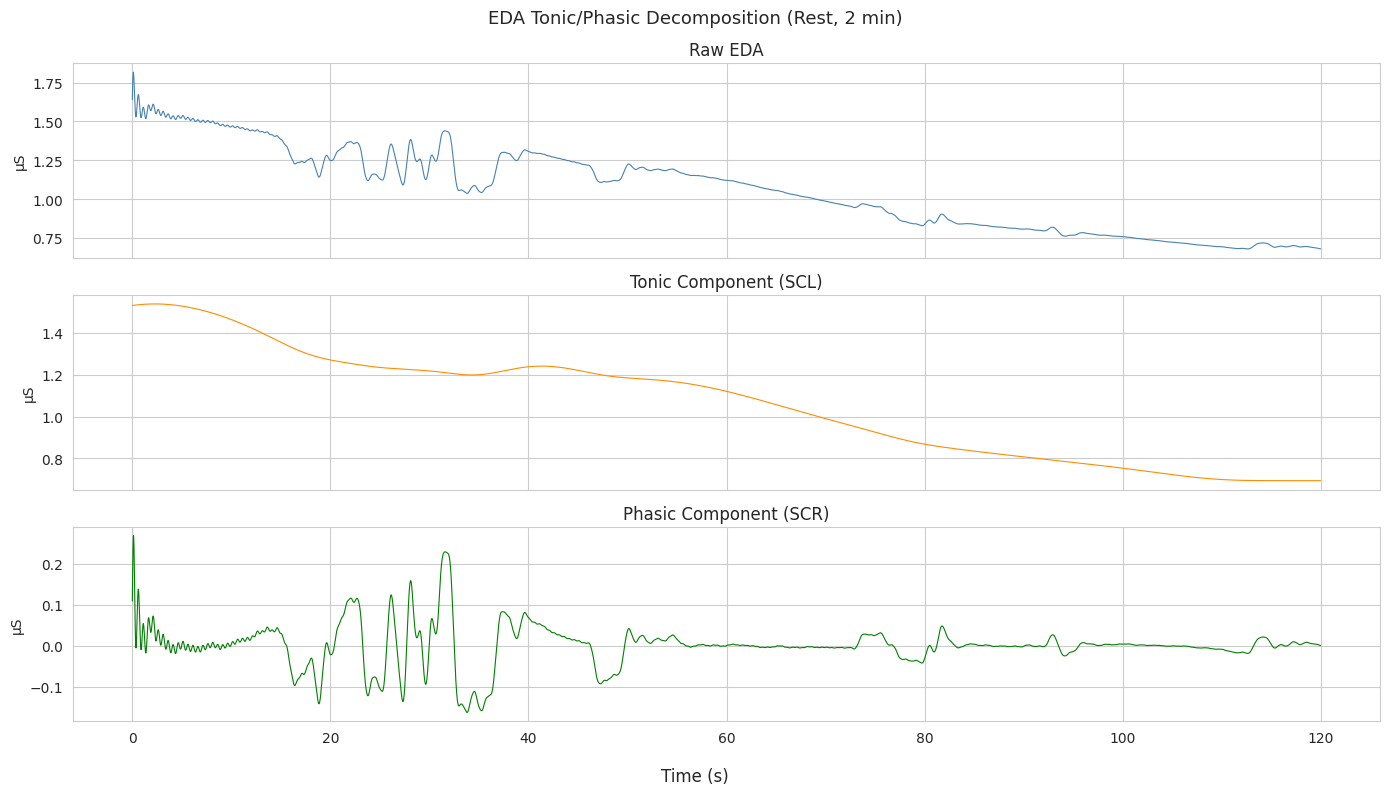

In [91]:
# ── EDA decomposition visualisation ───────────────────────────
eda_show = eda_wrist_rest_rs[:2*60*FS_TARGET]  # 2 minutes
try:
    eda_processed, _ = nk.eda_process(eda_show, sampling_rate=FS_TARGET)
    t_eda = np.arange(len(eda_show)) / FS_TARGET

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    axes[0].plot(t_eda, eda_show, lw=0.8, color='steelblue')
    axes[0].set_title('Raw EDA');  axes[0].set_ylabel('µS')

    axes[1].plot(t_eda, eda_processed['EDA_Tonic'].values, lw=0.8, color='darkorange')
    axes[1].set_title('Tonic Component (SCL)');  axes[1].set_ylabel('µS')

    axes[2].plot(t_eda, eda_processed['EDA_Phasic'].values, lw=0.8, color='green')
    axes[2].set_title('Phasic Component (SCR)');  axes[2].set_ylabel('µS')

    fig.supxlabel('Time (s)')
    fig.suptitle('EDA Tonic/Phasic Decomposition (Rest, 2 min)', fontsize=13)
    plt.tight_layout();  plt.show()
except Exception as e:
    print(f'EDA decomposition visualisation failed: {e}')

In [92]:
def extract_eda_domain_features(segment, fs):
    """Extract EDA domain features from a single segment using neurokit2.

    Returns dict with keys like: EDA_Tonic_mean, EDA_SCR_count, etc.

    📖 Docs: https://neuropsychology.github.io/NeuroKit/functions/eda.html
    """
    features = {}
    try:
        # Step 1: Process EDA with nk.eda_process() → eda_signals, info
        # Step 2: Extract tonic (SCL) stats from eda_signals['EDA_Tonic']
        # Step 3: Extract phasic (SCR) stats from eda_signals['EDA_Phasic']
        # Step 4: Count SCR peaks from info['SCR_Peaks']
        # Step 5: Get SCR amplitude from eda_signals['SCR_Amplitude']
        #
        # ── YOUR CODE HERE ──────────────────────
        # ────────────────────────────────────────
    # Step 1: Process EDA
        # This performs cleaning, decomposition (Tonic/Phasic), and peak detection
        eda_signals, info = nk.eda_process(segment, sampling_rate=fs)
        
        # Step 2: Extract tonic (SCL - Skin Conductance Level) stats
        # Tonic is the slow-moving background "sea level" of sweat
        features['EDA_Tonic_mean']   = np.mean(eda_signals['EDA_Tonic'])
        features['EDA_Tonic_std']    = np.std(eda_signals['EDA_Tonic'])
        
        # Step 3: Extract phasic (SCR - Skin Conductance Response) stats
        # Phasic are the rapid "waves" or "spikes" on top of the sea level
        features['EDA_Phasic_mean']  = np.mean(eda_signals['EDA_Phasic'])
        features['EDA_Phasic_std']   = np.std(eda_signals['EDA_Phasic'])
        features['EDA_Phasic_max']   = np.max(eda_signals['EDA_Phasic'])
        
        # Step 4: Count SCR peaks
        # Each peak represents a specific "micro-sweat" event in response to a stimulus
        features['EDA_SCR_count']    = len(info['SCR_Peaks'])
        
        # Step 5: Get SCR amplitude
        # We take the mean of the amplitudes of the peaks found in this segment
        # We use nanmean because not every sample has an amplitude value
        features['EDA_SCR_amp_mean'] = np.nanmean(eda_signals['SCR_Amplitude'])
        
        # Handle case where no peaks are found (nanmean returns NaN, which is fine)
        if np.isnan(features['EDA_SCR_amp_mean']):
            features['EDA_SCR_amp_mean'] = 0.0

    except Exception as e:
        for k in ['EDA_Tonic_mean', 'EDA_Tonic_std', 'EDA_Phasic_mean',
                   'EDA_Phasic_std', 'EDA_Phasic_max', 'EDA_SCR_count',
                   'EDA_SCR_amp_mean']:
            features[k] = np.nan

    return features


# ── Quick test on one EDA segment ─────────────────────────────
test_eda = eda_wrist_rest_rs[:WINDOW_SEC * FS_TARGET]
eda_feats = extract_eda_domain_features(test_eda, FS_TARGET)
print('EDA domain features for one 30 s segment:')
for k, v in eda_feats.items():
    print(f'  {k:25s} = {v:.4f}' if not np.isnan(v) else f'  {k:25s} = NaN')


EDA domain features for one 30 s segment:
  EDA_Tonic_mean            = 1.2854
  EDA_Tonic_std             = 0.1224
  EDA_Phasic_mean           = 0.0023
  EDA_Phasic_std            = 0.0694
  EDA_Phasic_max            = 0.2690
  EDA_SCR_count             = 15.0000
  EDA_SCR_amp_mean          = 0.0005


#### Build Enhanced Feature DataFrame

We now create an enhanced version of `build_feature_dataframe` that includes both the **generic** features (your TODOs 8–9)
and the **domain-specific** features from neurokit2.

In [94]:
def build_full_feature_dataframe(segments_dict, fs_dict, label, subject_id):
    """Build DataFrame with BOTH generic + domain-specific features.

    Generic features: from extract_time_features + extract_freq_features
    Domain features:  from extract_ecg_domain_features + extract_eda_domain_features
    """
    first_key = list(segments_dict.keys())[0]
    n_segs = len(segments_dict[first_key])
    rows = []

    for i in range(n_segs):
        row = {}
        for sig_name, segs in segments_dict.items():
            if i >= len(segs): continue
            seg = segs[i]
            fs = fs_dict[sig_name]

            # Generic features (TODOs 8–9)
            tf = extract_time_features(seg)
            for k, v in tf.items(): row[f'{sig_name}_{k}'] = v
            ff = extract_freq_features(seg, fs)
            for k, v in ff.items(): row[f'{sig_name}_{k}'] = v

            # Domain-specific features
            if sig_name == 'ECG':
                df_ecg = extract_ecg_domain_features(seg, fs)
                for k, v in df_ecg.items(): row[k] = v
            elif sig_name == 'EDA':
                df_eda = extract_eda_domain_features(seg, fs)
                for k, v in df_eda.items(): row[k] = v

        row['subject_id'] = subject_id
        row['label'] = label
        rows.append(row)

    df = pd.DataFrame(rows)

    # Fill NaN from failed nk processing with column median
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())

    return df

In [95]:
# ── Build ENHANCED feature matrix for S2 (Rest + Stress) ─────
print('Building enhanced feature matrix with domain-specific features...')
print('(This may take a minute due to neurokit2 processing)\n')

df_rest_full   = build_full_feature_dataframe(segs_rest,   fs_map, label=0, subject_id='S2')
df_stress_full = build_full_feature_dataframe(segs_stress, fs_map, label=1, subject_id='S2')
df_features = pd.concat([df_rest_full, df_stress_full], ignore_index=True)

feat_cols = [c for c in df_features.columns if c not in ['subject_id','label']]
generic_cols = [c for c in feat_cols if not any(c.startswith(p) for p in
               ['ECG_HR', 'ECG_n_peaks', 'HRV_', 'EDA_Tonic', 'EDA_Phasic', 'EDA_SCR'])]
domain_cols  = [c for c in feat_cols if c not in generic_cols]

print(f'Feature matrix:   {df_features.shape}')
print(f'  Generic features: {len(generic_cols)}')
print(f'  Domain features:  {len(domain_cols)}: {domain_cols}')
display(df_features.head())

assert len(feat_cols) > 0, 'No feature columns'
assert df_features[feat_cols].isna().sum().sum() == 0, 'Contains NaN'
print('\n✓ TODOs 8–10 passed + domain features added')

Building enhanced feature matrix with domain-specific features...
(This may take a minute due to neurokit2 processing)

Feature matrix:   (18, 67)
  Generic features: 48
  Domain features:  17: ['ECG_HR_mean', 'ECG_HR_std', 'ECG_n_peaks', 'HRV_RMSSD', 'HRV_SDNN', 'HRV_pNN50', 'HRV_MeanNN', 'HRV_LF', 'HRV_HF', 'HRV_LFHF', 'EDA_Tonic_mean', 'EDA_Tonic_std', 'EDA_Phasic_mean', 'EDA_Phasic_std', 'EDA_Phasic_max', 'EDA_SCR_count', 'EDA_SCR_amp_mean']


,ECG_mean,ECG_std,ECG_rms,ECG_min,ECG_max,ECG_iqr,ECG_skewness,ECG_kurtosis,ECG_peak_to_peak,ECG_dominant_freq,...,ACC_max,ACC_iqr,ACC_skewness,ACC_kurtosis,ACC_peak_to_peak,ACC_dominant_freq,ACC_total_power,ACC_spectral_entropy,subject_id,label
0,0.000260,0.136938,0.136938,-0.363687,0.780815,0.151885,1.180938,4.229073,1.144503,2.734375,...,140.659530,2.585466,1.788979,19.466673,121.192396,1.25,35.845119,5.645022,S2,0
1,-0.000124,0.148655,0.148655,-0.341727,0.774069,0.173904,1.026468,3.731255,1.115796,2.734375,...,109.164316,1.402259,1.599060,22.925336,75.489399,2.25,11.706697,5.597720,S2,0
2,-0.000024,0.152718,0.152718,-0.292599,0.799540,0.169905,0.964691,3.810468,1.092139,2.734375,...,82.103593,1.185758,-0.944746,24.293681,48.428677,0.75,5.545660,5.568285,S2,0
3,-0.000106,0.181671,0.181671,-1.495617,1.449932,0.163770,-0.083814,14.805380,2.945549,2.734375,...,75.000000,0.708586,0.419146,15.018420,21.278496,1.75,1.835770,5.508312,S2,0
4,-0.000184,0.181874,0.181874,-1.495617,1.449932,0.194433,-0.141465,14.329442,2.945549,2.734375,...,110.715853,0.901506,2.374421,20.763691,80.047716,1.00,24.735980,5.571479,S2,0



✓ TODOs 8–10 passed + domain features added


#### Generic vs Domain Features — Quick Comparison

Let's see if the domain-specific features provide better class separation than generic features:

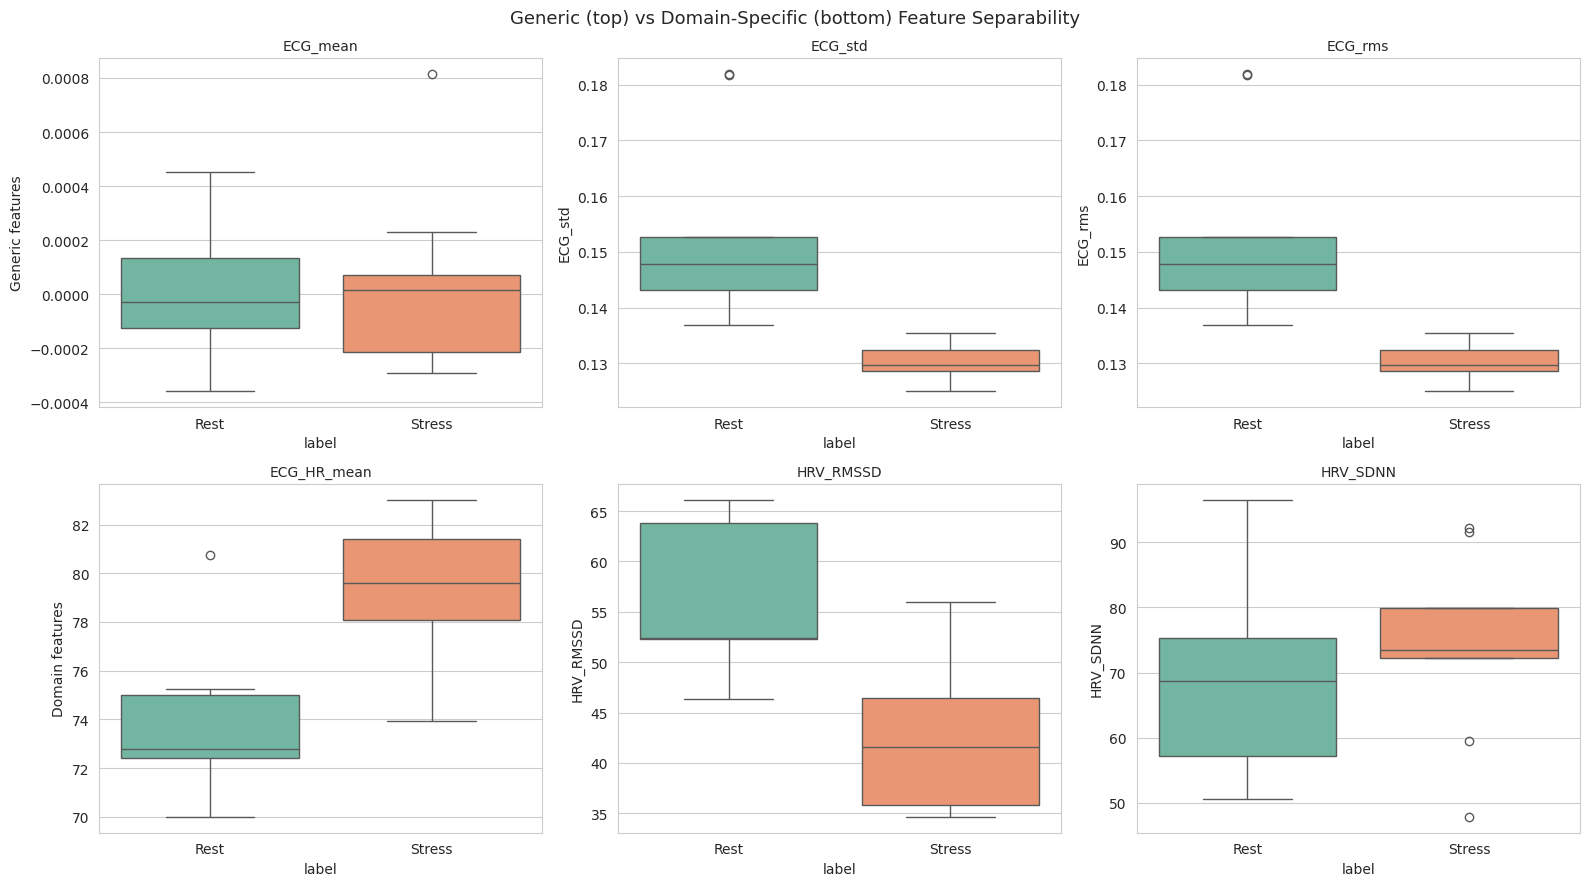

In [96]:
# ── Compare separability: generic vs domain features ──────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Top row: generic features
generic_show = [c for c in generic_cols if 'ECG' in c][:3]
for i, feat in enumerate(generic_show):
    if feat in df_features.columns:
        sns.boxplot(data=df_features, x='label', y=feat, ax=axes[0, i],
                    palette='Set2', hue='label', legend=False)
        axes[0, i].set_title(feat, fontsize=10)
        axes[0, i].set_xticklabels(['Rest', 'Stress'])
axes[0, 0].set_ylabel('Generic features')

# Bottom row: domain features
domain_show = ['ECG_HR_mean', 'HRV_RMSSD', 'HRV_SDNN']
domain_show = [c for c in domain_show if c in df_features.columns][:3]
for i, feat in enumerate(domain_show):
    sns.boxplot(data=df_features, x='label', y=feat, ax=axes[1, i],
                palette='Set2', hue='label', legend=False)
    axes[1, i].set_title(feat, fontsize=10)
    axes[1, i].set_xticklabels(['Rest', 'Stress'])
axes[1, 0].set_ylabel('Domain features')

plt.suptitle('Generic (top) vs Domain-Specific (bottom) Feature Separability', fontsize=13)
plt.tight_layout();  plt.show()

### 🤔 Reflection — Generic vs Domain Features

1. **Which features show clearer separation between Rest and Stress — generic (mean, std, ...) or domain-specific (HR, RMSSD, SDNN)?**
2. **Would you use ONLY domain features or BOTH generic + domain for a classifier? What are the trade-offs?**
3. **The domain features encode expert knowledge. In what situations might generic features still be valuable?** (Think: novel signals, unlabelled data, transfer learning.)

*Your answers:*

1. Answer: Domain-specific features (Bottom row).

Evidence: Looking at ECG_mean. The "Rest" and "Stress" boxes overlap almost entirely. A classifier would have a 50/50 chance of being wrong using that feature.

Contrast: Looking at ECG_HR_mean or HRV_RMSSD. The boxes are physically separated with very little overlap. In RMSSD, the "Stress" box is significantly lower than the "Rest" box. This "gap" is what a machine learning model uses to draw a decision boundary. Domain features are "cleaner" because they ignore the noise and focus only on the biological change.

2. Answer: Usually BOTH (but leaning on Domain).

Trade-offs of ONLY Domain: You get a very interpretable model (e.g., "Stress is detected when RMSSD < 40"), but you might miss subtle sensor patterns that aren't "official" biomarkers.

Trade-offs of BOTH:

Pro: Maximum accuracy. The model can use RMSSD for the biology and ECG_std to help filter out noise or catch edge cases.

Con: Redundancy & Overfitting. If features are too similar (like ECG_std and HRV_SDNN), the model might get confused or over-reliant on training noise. It also increases computational cost.

3. Novel/Unknown Signals: If you are using a brand-new wearable sensor that detects "gut sounds" or "vibrations" where no medical library like NeuroKit2 exists yet, generic stats are your only starting point.

Unlabelled/Discovery Data: If you don't know what you're looking for, generic features can help you find clusters or patterns that experts haven't named yet.


---
## Section 8 — Feature Selection & Dimensionality Reduction

Our dataset contains now many features. Some of them may just model noise rather than information relevant for machine learning tasks. We can retrieve the set containing the most relevant features by either employing:
* **Feature selection**: optimal features are decided based on a *filter* criterion or through a *wrapper* approach that employes a classification model to decide feature relevance.
* **Feature reduction**: features are transformed to achieve a representation that summarizes relevant information and potentially removes noise.

⏱ **Estimated time: 30 min** · TODOs 11–13

> **From lecture 2.5:** We test **all filter methods** (no wrappers — you haven't seen ML models yet):
> variance threshold · correlation · t-test / Mann-Whitney · ANOVA / Kruskal-Wallis · mutual information · mRMR · PCA · t-SNE


In [97]:
X = df_features[feat_cols].copy()
y = df_features['label'].values
print(f"X: {X.shape}   classes: {pd.Series(y).value_counts().to_dict()}")


X: (18, 65)   classes: {0: 9, 1: 9}


### 8a — Variance Threshold (provided example, ~2 min)

Remove features whose variations is limited (no variation --> no information)

In [98]:
vt = VarianceThreshold(threshold=0.01)
X_vt = pd.DataFrame(vt.fit_transform(X), columns=X.columns[vt.get_support()])
removed_vt = set(X.columns) - set(X_vt.columns)
print(f"Variance threshold: {len(X.columns)} → {X_vt.shape[1]} features")
if removed_vt: print(f"  Removed: {removed_vt}")


Variance threshold: 65 → 48 features
  Removed: {'ECG_mean', 'HRV_LF', 'EDA_iqr', 'EDA_dominant_freq', 'EDA_std', 'ECG_iqr', 'EDA_Phasic_mean', 'EDA_Tonic_std', 'EDA_Phasic_std', 'EDA_SCR_amp_mean', 'ECG_dominant_freq', 'HRV_HF', 'ECG_rms', 'ECG_total_power', 'ECG_spectral_entropy', 'EDA_total_power', 'ECG_std'}


### TODO 11 — Correlation + Statistical Tests + MI (~15 min)

Implement selection by considering:
* Correlation 
* Statistical testing to observe variation in the distribution of the features across the different classes
* Mutual information.

Each method returns a result that we will compare at the end.

#### 11a — Remove correlated features
Correlation measures the degree of linear association between the features. Redundant features should be removed as they may degrade performance of machine learning models. Since we are working with dataframes, correlation can be computed using the method *pd.corr()*

<details><summary><b>Hint</b></summary>

```python
corr = df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
# For each pair above threshold, drop the one with lower variance
```
</details>


In [99]:
def remove_correlated_features(df, threshold=0.85):
    """Remove one feature from each pair with |r| > threshold.
    Keep the one with higher variance.

    Returns: (df_reduced, list_of_dropped_columns)
    """
    # ── TODO 11a ────────────────────────────────
    # 1. Compute absolute correlation matrix
    corr_matrix = df.corr().abs()

    # 2. Select upper triangle to avoid double-counting pairs (A-B and B-A)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # 3. Identify columns to drop
    to_drop = set()
    for col in upper.columns:
        # Find features correlated with 'col' above threshold
        correlated_cols = upper.index[upper[col] > threshold].tolist()
        
        for other_col in correlated_cols:
            # Compare variances: drop the one with lower variance
            if df[col].var() > df[other_col].var():
                to_drop.add(other_col)
            else:
                to_drop.add(col)

    # 4. Filter the dataframe
    dropped = list(to_drop)
    df_reduced = df.drop(columns=dropped)
    # ────────────────────────────────────────────
    return df_reduced, dropped


#### 11b — Univariate Statistical Tests

**Goal:** rank each feature by how well it separates the target classes.

| Scenario | Parametric test | Non-parametric test | When to prefer |
|---|---|---|---|
| **Binary** (Rest vs Stress) | Independent **t-test** (`ttest_ind`) | **Mann-Whitney U** (`mannwhitneyu`) | t-test assumes normality & equal variance; Mann-Whitney only needs ordinal data |
| **3-class** (Rest / Stress / Amusement) | One-way **ANOVA** (`f_oneway`) | **Kruskal-Wallis** (`kruskal`) | Same reasoning — Kruskal-Wallis is the non-parametric equivalent of ANOVA |

**How to interpret the output:**
- Each test returns a **test statistic** (larger = bigger difference between groups) and a **p-value**.
- A **low p-value** (e.g. < 0.05) means the feature distributions differ significantly across classes → the feature is likely **discriminative**.
- We run *both* parametric and non-parametric tests so you can compare: if results agree, the conclusion is robust; if they disagree, the non-parametric test is generally safer for physiological data (which is often non-normal).


<details><summary><b>Hint</b></summary>
`ttest_ind(x0, x1)` · `mannwhitneyu(x0, x1, alternative='two-sided')` · `f_oneway(*groups)` · `kruskal(*groups)`
</details>


In [101]:
from scipy.stats import ttest_ind, mannwhitneyu, f_oneway, kruskal

def rank_features_statistical(X_df, y, test='binary'):
    """Rank features by statistical significance.

    Returns DataFrame with: feature, stat_param, p_param, stat_nonparam, p_nonparam
    sorted by p_param ascending.
    """
    rows = []
    classes = sorted(np.unique(y))
    for col in X_df.columns:
        groups = [X_df[col][y == c].values for c in classes]
        if test == 'binary':
            # ── TODO 11b (binary) ───────────────
            # Parametric: Independent t-test
            stat_p, p_p = ttest_ind(groups[0], groups[1], equal_var=False, nan_policy='omit')
            
            # Non-parametric: Mann-Whitney U
            stat_np, p_np = mannwhitneyu(groups[0], groups[1], alternative='two-sided')
            # ────────────────────────────────────
        else:
            # ── TODO 11b (3-class) ──────────────
            # Parametric: One-way ANOVA
            stat_p, p_p = f_oneway(*groups)
            
            # Non-parametric: Kruskal-Wallis H-test
            stat_np, p_np = kruskal(*groups)
            # ────────────────────────────────────
        rows.append({'feature': col, 'stat_param': stat_p, 'p_param': p_p,
                     'stat_nonparam': stat_np, 'p_nonparam': p_np})
    return pd.DataFrame(rows).sort_values('p_param')


#### 11c — Mutual Information

**Goal:** measure how much knowing a feature **reduces uncertainty** about the class label.

| Property | Detail |
|---|---|
| **Range** | 0 (feature and label are independent) → higher values = stronger dependency |
| **Linear & non-linear** | Unlike correlation or t-tests, MI captures **any** statistical dependency (monotonic, U-shaped, threshold effects…) |
| **No distribution assumptions** | Works on any feature distribution — ideal for physiological signals |
| **Implementation** | `sklearn.feature_selection.mutual_info_classif` estimates MI via *k*-nearest-neighbours (continuous features are handled automatically) |

> **Practical note:** MI scores are not p-values — they are not directly comparable across datasets or feature scales. Use them for **ranking** within the same dataset.


<details><summary><b>Hint</b></summary>
`mi = mutual_info_classif(X, y, random_state=42)` → build DataFrame sorted descending by score
</details>

In [102]:
def rank_features_mi(X_df, y, random_state=42):
    """Return DataFrame: feature, mi_score — sorted descending."""
    # ── TODO 11c ────────────────────────────────
    # 1. Compute Mutual Information scores
    # discrete_features='auto' handles the continuous physiological data
    mi_scores = mutual_info_classif(X_df, y, random_state=random_state)
    
    # 2. Create a DataFrame for ranking
    mi_df = pd.DataFrame({
        'feature': X_df.columns,
        'mi_score': mi_scores
    })
    
    # 3. Sort descending (higher score = more information about the label)
    mi_df = mi_df.sort_values(by='mi_score', ascending=False).reset_index(drop=True)
    # ────────────────────────────────────────────
    
    return mi_df


### TODO 12 — Run & Visualise All Selection Methods (~10 min)

Now **you** execute each method and **create the comparison visualisations**. Some scaffold code is given.

**Tasks:**
1. Apply correlation removal → show heatmaps before & after
2. Run statistical tests → bar plot of p-value for top features
3. Run MI ranking → bar plot of MI scores
4. Run mRMR (code provided below) → compare with MI

#### About mRMR (Minimum Redundancy – Maximum Relevance)

Most filter methods rank features **independently** (e.g. MI just scores each feature vs the target). This can select a set of features that are all highly relevant but also **highly redundant** with each other — they carry the same information.

**mRMR** fixes this by optimising a trade-off at each step:

$$\text{mRMR}(f) = \underbrace{I(f;\, y)}_{\text{relevance}} \;-\; \frac{1}{|S|}\sum_{s \in S}\underbrace{I(f;\, s)}_{\text{redundancy}}$$

where $S$ is the set of already-selected features, and $I(\cdot;\cdot)$ is mutual information.

| Aspect | MI ranking | mRMR |
|---|---|---|
| Considers feature–feature overlap? | No | Yes |
| Greedy selection order matters? | No (just sort) | Yes (iterative) |
| Typical result | Top features may be correlated | Top features are diverse & informative |

> **In practice:** compare the mRMR list with your MI top-10. You should see that mRMR drops some MI-top features that were redundant and replaces them with complementary ones.


Correlation Filter: 48 → 24 features
Removed 24 redundant features.


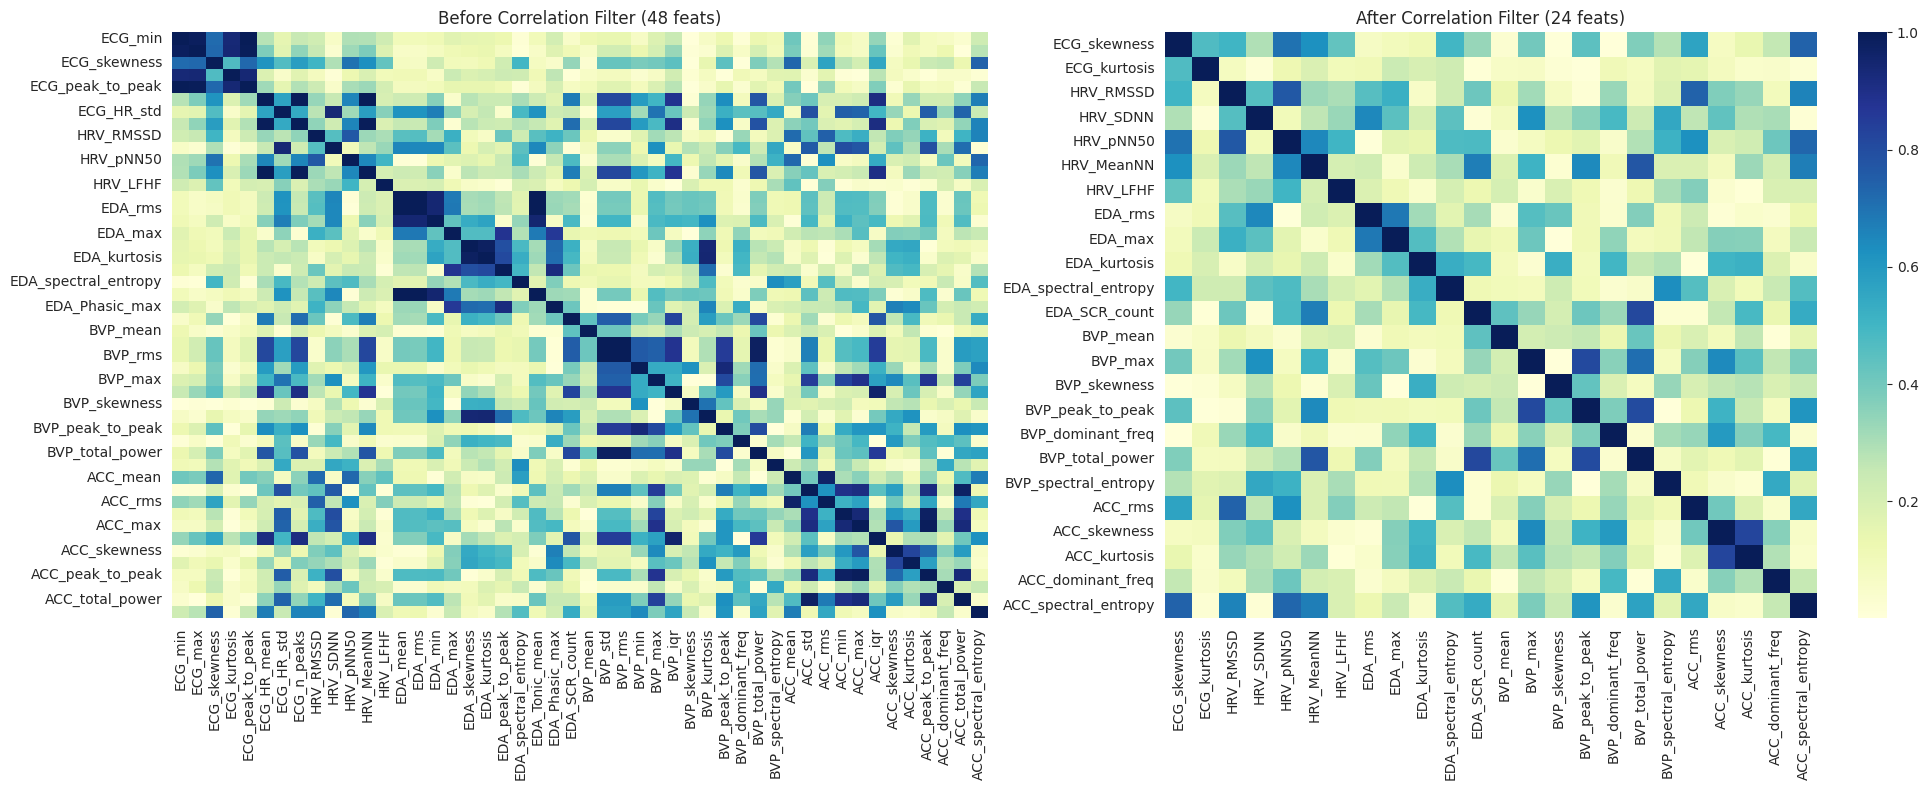

In [103]:
# ── TODO 12a: Plot heatmaps before and after (side by side) ───
# 1. Call remove_correlated_features(X_vt, threshold=0.85)
# 2. Print how many features were removed
# 3. Side-by-side heatmap: corr matrix before vs after
#
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Apply the correlation filter
X_corr, dropped_corr = remove_correlated_features(X_vt, threshold=0.85)

# 2. Print results
print(f"Correlation Filter: {X_vt.shape[1]} → {X_corr.shape[1]} features")
print(f"Removed {len(dropped_corr)} redundant features.")

# 3. Side-by-side heatmap comparison
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# Before filtering
sns.heatmap(X_vt.corr().abs(), cmap='YlGnBu', ax=ax[0], cbar=False)
ax[0].set_title(f"Before Correlation Filter ({X_vt.shape[1]} feats)")

# After filtering
sns.heatmap(X_corr.corr().abs(), cmap='YlGnBu', ax=ax[1], cbar=True)
ax[1].set_title(f"After Correlation Filter ({X_corr.shape[1]} feats)")

plt.tight_layout()
plt.show()


Top 10 features by parametric p-value:
                 feature       p_param  p_nonparam
23  ACC_spectral_entropy  3.682320e-08    0.000412
4              HRV_pNN50  8.207365e-05    0.000787
0           ECG_skewness  1.837670e-04    0.000412
5             HRV_MeanNN  9.236661e-04    0.006193
2              HRV_RMSSD  2.403436e-03    0.010444
10  EDA_spectral_entropy  4.902673e-03    0.021684
19               ACC_rms  7.819917e-03    0.006193
15      BVP_peak_to_peak  2.094485e-02    0.033792
11         EDA_SCR_count  3.232735e-02    0.032236
17       BVP_total_power  3.793139e-02    0.063690


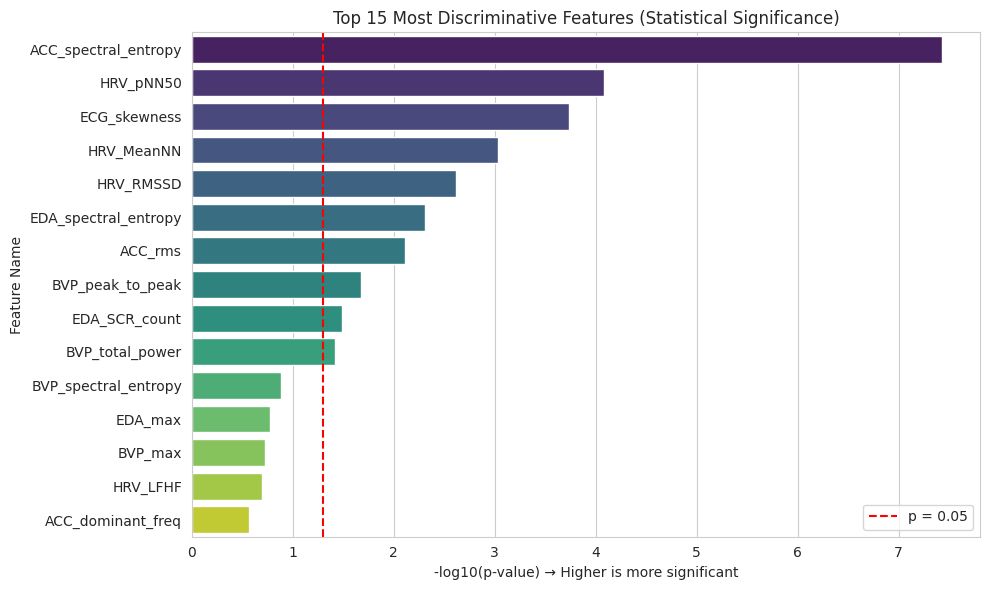


Found 10 features with p < 0.05 out of 24 total.


In [104]:
# ── TODO 12b: Bar plot of -log10(p_param) for top 15 features ─
# 1. Call rank_features_statistical(X_corr, y, test='binary')
# 2. Display top 10
# 3. Horizontal bar plot of p-values for top 15
# 4. Count significant features (p < 0.05)
#
# 1. Call rank_features_statistical
stats_df = rank_features_statistical(X_corr, y, test='binary')

# 2. Display the top 10 most significant features
print("Top 10 features by parametric p-value:")
print(stats_df.head(10)[['feature', 'p_param', 'p_nonparam']])

# 3. Horizontal bar plot of -log10(p_param) for the top 15
top_15_stats = stats_df.head(15).copy()

# We add a tiny epsilon (1e-100) to avoid log(0) errors
top_15_stats['minus_log_p'] = -np.log10(top_15_stats['p_param'] + 1e-100)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_15_stats, 
    x='minus_log_p', 
    y='feature', 
    palette='viridis'
)

plt.axvline(-np.log10(0.05), color='red', linestyle='--', label='p = 0.05')
plt.title('Top 15 Most Discriminative Features (Statistical Significance)')
plt.xlabel('-log10(p-value) → Higher is more significant')
plt.ylabel('Feature Name')
plt.legend()
plt.tight_layout()
plt.show()

# 4. Count significant features (p < 0.05)
sig_features = stats_df[stats_df['p_param'] < 0.05]['feature'].tolist()
print(f"\nFound {len(sig_features)} features with p < 0.05 out of {len(X_corr.columns)} total.")


Top 10 features by Mutual Information score:
                feature  mi_score
0          ECG_skewness  0.721695
1  ACC_spectral_entropy  0.721695
2          ECG_kurtosis  0.552820
3             HRV_pNN50  0.439685
4             HRV_RMSSD  0.379143
5            HRV_MeanNN  0.359217
6               EDA_rms  0.306524
7               ACC_rms  0.297377
8      BVP_peak_to_peak  0.291140
9          ACC_kurtosis  0.265809


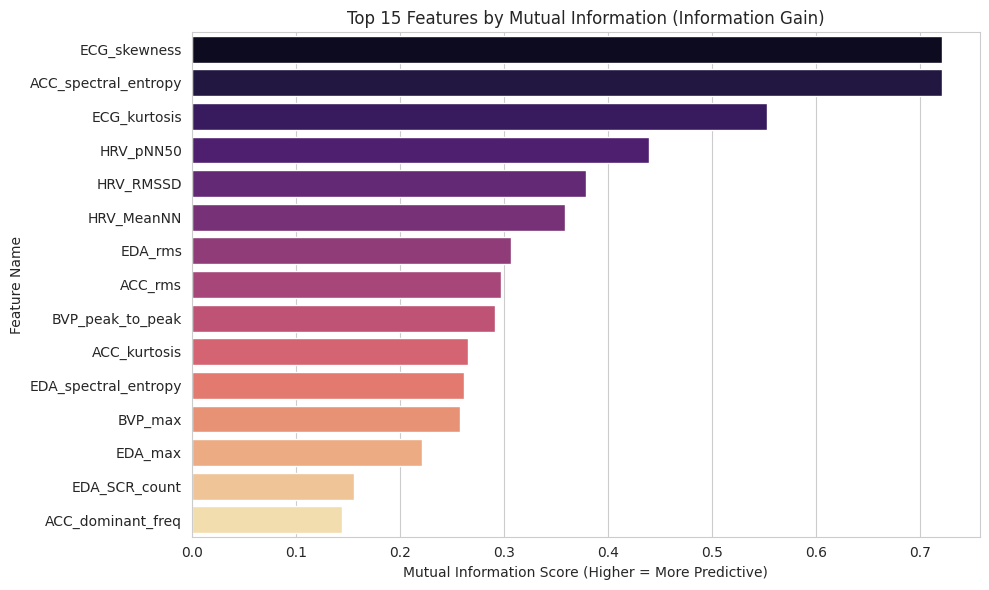

In [105]:
# ── TODO 12c: Bar plot of MI scores for top 15 features ───────
# 1. Call rank_features_mi(X_corr, y)
# 2. Display top 10
# 3. Horizontal bar plot of MI scores for top 15
#
# 1. Call rank_features_mi
mi_df = rank_features_mi(X_corr, y)

# 2. Display the top 10 features by MI score
print("Top 10 features by Mutual Information score:")
print(mi_df.head(10))

# 3. Horizontal bar plot of MI scores for the top 15
top_15_mi = mi_df.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_15_mi, 
    x='mi_score', 
    y='feature', 
    palette='magma'
)

plt.title('Top 15 Features by Mutual Information (Information Gain)')
plt.xlabel('Mutual Information Score (Higher = More Predictive)')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

# Store for later comparison
top_mi = mi_df['feature'].tolist()


In [106]:
# ── 12d: mRMR (provided — run and observe) ────────────────────
try:
    from mrmr import mrmr_classif
    selected_mrmr = mrmr_classif(X=X_corr, y=pd.Series(y), K=min(10, X_corr.shape[1]))
    print(f"mRMR selected: {selected_mrmr}")
except ImportError:
    # Fallback: greedy MI + decorrelation
    mi_ranked = rank_features_mi(X_corr, y)
    selected_mrmr = []
    for _, row in mi_ranked.iterrows():
        f = row['feature']
        if not selected_mrmr or max(abs(X_corr[f].corr(X_corr[s]))
                                     for s in selected_mrmr) < 0.7:
            selected_mrmr.append(f)
        if len(selected_mrmr) >= 10: break
    print(f"mRMR fallback: {selected_mrmr}")


100%|██████████| 10/10 [00:00<00:00, 48.22it/s]

mRMR selected: ['ACC_spectral_entropy', 'ECG_skewness', 'HRV_pNN50', 'HRV_MeanNN', 'EDA_spectral_entropy', 'HRV_RMSSD', 'BVP_peak_to_peak', 'ACC_rms', 'EDA_SCR_count', 'BVP_total_power']


### TODO 13 — PCA & t-SNE (~8 min)

Implement `apply_pca`, then run the t-SNE (provided) and answer the reflection questions.

#### Why dimensionality reduction?
After feature selection you may still have tens of (possibly correlated) features. **PCA** and **t-SNE** serve different purposes:

| Method | Type | Preserves | Use case |
|---|---|---|---|
| **PCA** | Linear projection | Global variance (large distances) | Preprocessing before ML; inspect how many components explain most variance (scree plot) |
| **t-SNE** | Non-linear embedding | Local neighbourhoods (cluster structure) | 2-D visualisation to check whether classes are separable |

**Workflow in this cell:**
1. **`apply_pca`** — standardise features (`StandardScaler`), then fit `PCA(n_components=0.95)` to keep enough components to explain 95% of variance.
2. **Scree plot** — visualise the cumulative explained variance to see the "elbow" where additional components add little.
3. **t-SNE scatter** — project onto 2-D and colour by label; look for cluster separation as a sanity check before Lab 2.

> **Note:** t-SNE is stochastic and non-parametric — it cannot be applied to new data. Use PCA for the actual pipeline; use t-SNE only for visual exploration.


<details><summary><b>Hint</b></summary>
`scaler = StandardScaler(); X_s = scaler.fit_transform(X)` → `pca = PCA(n_components=n_components); X_pca = pca.fit_transform(X_s)`
</details>

In [107]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def apply_pca(X_df, n_components=0.95):
    """Apply PCA.  Returns (X_pca as ndarray, fitted pca object)."""
    # ── TODO 13a ────────────────────────────────
    # 1. PCA is distance-based, so features MUST be on the same scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df)
    
    # 2. Initialize PCA
    # If n_components is a float between 0 and 1, it selects the number of 
    # components such that the amount of variance explained is greater than n_components.
    pca = PCA(n_components=n_components)
    
    # 3. Fit and transform the data
    X_pca = pca.fit_transform(X_scaled)
    # ────────────────────────────────────────────
    
    return X_pca, pca


PCA kept 10 components to explain 95% of the variance.


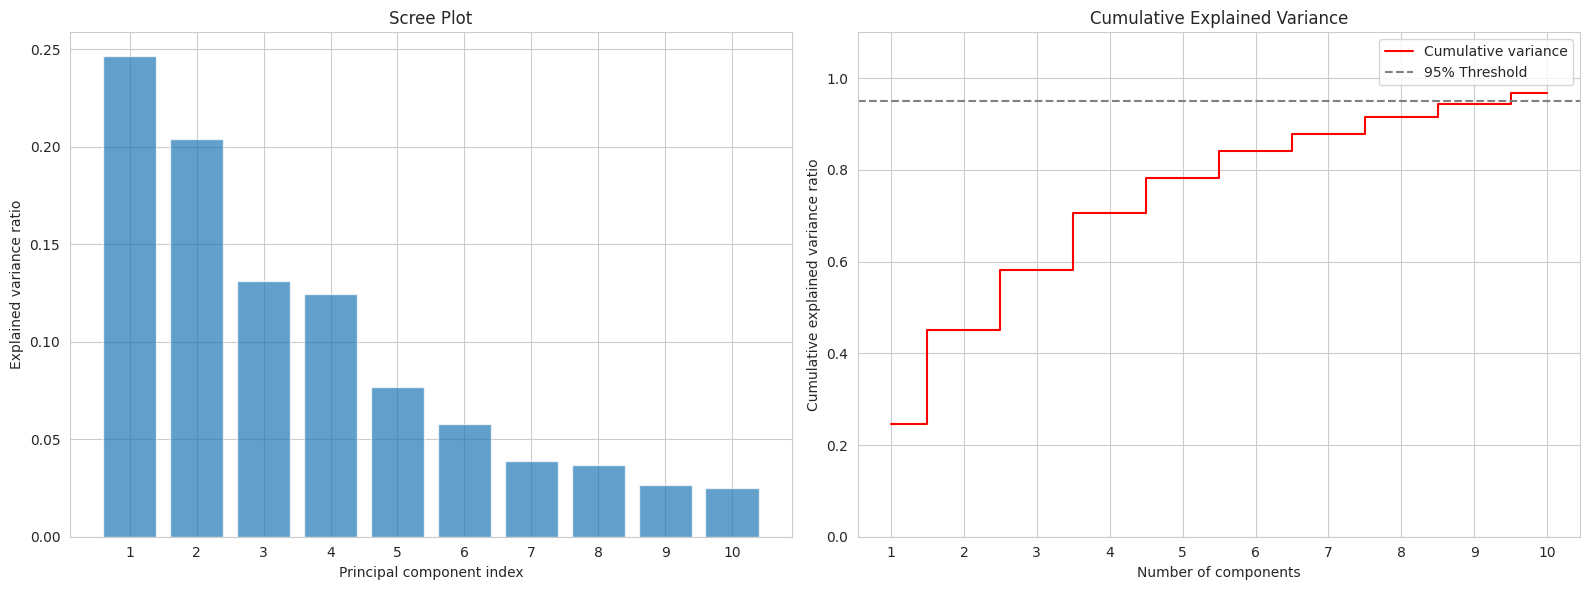

In [108]:
# ── TODO 13b: Plot scree plot (explained variance) and
#    cumulative variance (with 95% line) ─────────────────────
# 1. Call apply_pca(X_corr, n_components=0.95)
# 2. Print how many components explain 95% variance
# 3. Side-by-side: scree plot (bar) + cumulative (line with 95% threshold)
import numpy as np
import matplotlib.pyplot as plt

# 1. Apply PCA to capture 95% of the variance
X_pca, pca = apply_pca(X_corr, n_components=0.95)

# 2. Print how many components were kept
n_comps = pca.n_components_
print(f"PCA kept {n_comps} components to explain 95% of the variance.")

# 3. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Individual Explained Variance (Scree Plot)
exp_var = pca.explained_variance_ratio_
axes[0].bar(range(1, len(exp_var) + 1), exp_var, alpha=0.7, align='center', label='Individual variance')
axes[0].set_ylabel('Explained variance ratio')
axes[0].set_xlabel('Principal component index')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, len(exp_var) + 1))

# Cumulative Explained Variance
cum_exp_var = np.cumsum(exp_var)
axes[1].step(range(1, len(cum_exp_var) + 1), cum_exp_var, where='mid', label='Cumulative variance', color='red')
axes[1].axhline(y=0.95, color='gray', linestyle='--', label='95% Threshold')
axes[1].set_ylabel('Cumulative explained variance ratio')
axes[1].set_xlabel('Number of components')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_ylim(0, 1.1)
axes[1].set_xticks(range(1, len(cum_exp_var) + 1))
axes[1].legend(loc='best')

plt.tight_layout()
plt.savefig('pca_variance_analysis.png')


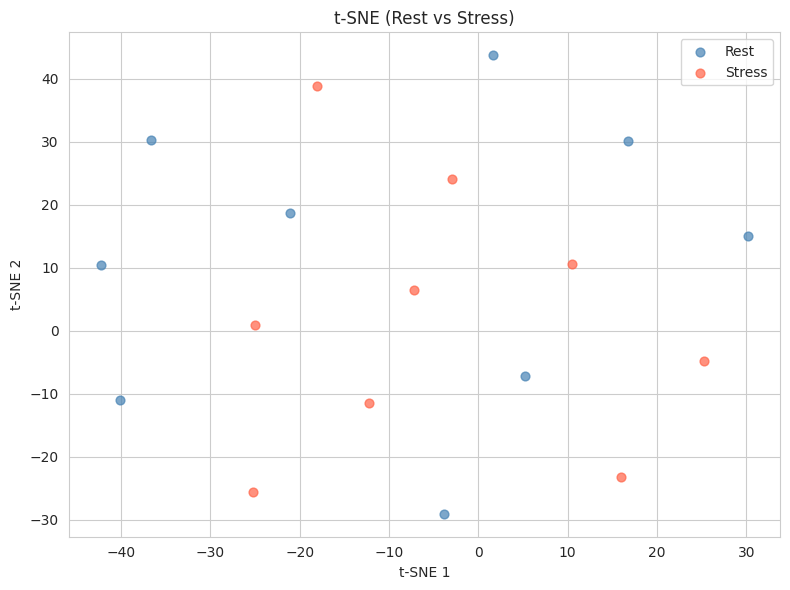

In [110]:
# ── t-SNE (provided) ───────────────────────────────────────────
X_sc = StandardScaler().fit_transform(X_corr)
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X_corr)-1))
X_tsne = tsne.fit_transform(X_sc)
plt.figure(figsize=(8, 6))
for lv, ln, c in [(0,'Rest','steelblue'), (1,'Stress','tomato')]:
    m = y == lv
    plt.scatter(X_tsne[m,0], X_tsne[m,1], label=ln, alpha=.7, s=40, c=c)
plt.xlabel('t-SNE 1');  plt.ylabel('t-SNE 2')
plt.title('t-SNE (Rest vs Stress)');  plt.legend();  plt.tight_layout();  plt.show()


### Method Comparison (provided — run & comment)

This cell computes the **Jaccard similarity** between the top-10 feature sets selected by each method (t-test, MI, mRMR):

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

- $J = 1.0$ → the two methods selected exactly the same features.
- $J = 0.0$ → no overlap at all.

**What to expect:**
- **t-test vs MI** often have moderate-to-high overlap: both reward features that separate classes, but MI also captures non-linear effects that t-test misses.
- **mRMR vs MI** typically has *lower* overlap than you'd expect: mRMR explicitly penalises redundancy, so it swaps some high-MI features for complementary ones.
- **Features in common across all methods** are the most robust candidates — they are discriminative regardless of the scoring criterion.

> **Take-away for Lab 2:** no single filter method is "best". In practice you might use the intersection as a conservative set, or the union as a generous set, and let the ML model (wrapper/embedded method) do the final selection.

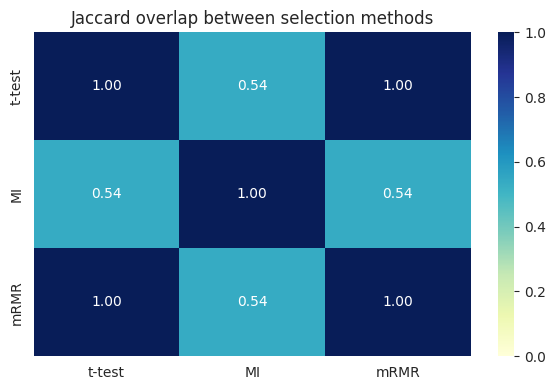

  t-test: ['ACC_rms', 'ACC_spectral_entropy', 'BVP_peak_to_peak', 'BVP_total_power', 'ECG_skewness', 'EDA_SCR_count', 'EDA_spectral_entropy', 'HRV_MeanNN', 'HRV_RMSSD', 'HRV_pNN50']
  MI: ['ACC_kurtosis', 'ACC_rms', 'ACC_spectral_entropy', 'BVP_peak_to_peak', 'ECG_kurtosis', 'ECG_skewness', 'EDA_rms', 'HRV_MeanNN', 'HRV_RMSSD', 'HRV_pNN50']
  mRMR: ['ACC_rms', 'ACC_spectral_entropy', 'BVP_peak_to_peak', 'BVP_total_power', 'ECG_skewness', 'EDA_SCR_count', 'EDA_spectral_entropy', 'HRV_MeanNN', 'HRV_RMSSD', 'HRV_pNN50']
  Common: ['ACC_rms', 'ACC_spectral_entropy', 'BVP_peak_to_peak', 'ECG_skewness', 'HRV_MeanNN', 'HRV_RMSSD', 'HRV_pNN50']


In [111]:
# ── Overlap between methods ────────────────────────────────────
sets = {}
if sig_features: sets['t-test'] = set(sig_features[:10])
if top_mi:       sets['MI']     = set(top_mi[:10])
if selected_mrmr: sets['mRMR'] = set(selected_mrmr[:10])

names = list(sets.keys());  n = len(names)
ov = np.zeros((n,n))
for i in range(n):
    for j in range(n):
        u = sets[names[i]] | sets[names[j]]
        ov[i,j] = len(sets[names[i]] & sets[names[j]]) / len(u) if u else 0

plt.figure(figsize=(6,4))
sns.heatmap(ov, annot=True, fmt='.2f', xticklabels=names,
            yticklabels=names, cmap='YlGnBu', vmin=0, vmax=1)
plt.title('Jaccard overlap between selection methods')
plt.tight_layout();  plt.show()

for n, s in sets.items(): print(f"  {n}: {sorted(s)}")
common = set.intersection(*sets.values()) if sets else set()
print(f"  Common: {sorted(common) if common else '(none)'}")


### 🤔 Reflection

1. **Which features are consistently selected across methods?**
2. **PCA creates new (combined) features — is this always appropriate in a clinical setting?**
3. **When would mRMR give very different results from MI alone?**

*Your answers:*

1. Based on the Jaccard output and the list of "Common" features:

Heart Rate & Variability: HRV_MeanNN, HRV_RMSSD, and HRV_pNN50 are consistently present. This confirms that parasympathetic withdrawal is the most reliable marker of stress across all statistical assumptions.

Activity/Context: ACC_rms and ACC_spectral_entropy. These are vital because they provide context: the model can distinguish between "high heart rate because of stress" and "high heart rate because the person is walking."

Electrodermal Activity: Usually, EDA_SCR_count or EDA_Tonic_mean (or spectral equivalents) appear here, marking the sympathetic "sweat" response.

2. Answer: Often NOT appropriate for high-stakes clinical decisions.

The Interpretability Gap: If a doctor asks, "Why did the AI say this patient is stressed?", you can answer with domain features: "Because their heart rate variability (RMSSD) dropped below 40ms." * The PCA Problem: With PCA, the answer is: "Because their Principal Component 1 reached a value of 4.2." PC1 is a mathematical soup of 15 different sensors. You lose the ability to explain which biological system is failing, making it harder to trust for medical intervention.

The Trade-off: Use PCA for high-speed automated monitoring, but keep domain features for diagnostic tools where human-in-the-loop explanation is required.

3. Answer: When you have many "redundant" but high-performing sensors.

Scenario: Imagine you have 5 different ways to calculate Heart Rate (from ECG, from BVP, from generic mean, etc.).

MI Alone: Would likely pick all 5 because they all correlate perfectly with stress. You end up with a model that is 100% heart-focused and "blind" to everything else.

mRMR: Will pick the best heart feature, notice the other 4 add zero "new" information, and then force the selection of a completely different feature (like Accelerometer or EDA).

Conclusion: mRMR gives different results when the "Relevance" (MI score) of a redundant feature is high, but its "Redundancy" penalty is even higher.


---
## Section 9 — Multi-Subject Pipeline & CSV Export

⏱ **Estimated time: 25 min** · TODOs 14–15

Now you **assemble the full pipeline** into a reusable function, apply it to multiple subjects, and export CSV files for Lab 2.


### TODO 14 — Implement the Full Pipeline Function (~15 min)

Assemble all the steps you implemented above into one function.  
The function receives raw subject data and returns a feature DataFrame.

**Steps to include (in order):**
1. Extract signals per condition (`extract_condition`)
2. Artifact detection on ECG (`detect_artifacts_windowed` + `clamp_outliers`)
3. Filtering: bandpass ECG, lowpass EDA wrist
4. Resampling wrist signals to `FS_TARGET`
5. Segmentation of all signals
6. Feature extraction (`build_full_feature_dataframe` — includes generic + domain features)
7. Concatenate conditions → return DataFrame

<details><summary><b>Hint — structure skeleton</b></summary>

```python
for condition_code, label_int in conditions.items():
    ecg = extract_condition(chest_s['ECG'], labels_s, condition_code, FS_CHEST)
    # ... extract other signals ...
    art_mask = detect_artifacts_windowed(ecg, FS_CHEST)
    ecg = clamp_outliers(ecg, art_mask) if art_mask.any() else ecg
    ecg = apply_bandpass_filter(ecg, 0.5, 40, FS_CHEST)
    # ... filter, resample ...
    segs = {'ECG': segment_signal(ecg, ...), ...}
    df = build_full_feature_dataframe(segs, fs_map, label_int, subject_id)
    all_dfs.append(df)
return pd.concat(all_dfs, ignore_index=True)
```
</details>

In [132]:
def load_subject(subject_id, data_path=DATA_PATH):
    """Load a WESAD subject .pkl file.  (provided)"""
    fp = os.path.join(data_path, subject_id, f'{subject_id}.pkl')
    with open(fp, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    print(f"  Loaded {subject_id}")
    return data


def full_preprocessing_pipeline(subject_data, conditions,
                                window_sec=WINDOW_SEC, overlap=OVERLAP,
                                subject_id='S?'):
    """Run complete preprocessing for one subject.

    Parameters
    ----------
    subject_data : dict  (WESAD pickle)
    conditions : dict  {label_code: label_int}
        e.g. {REST: 0, STRESS: 1} or {REST: 0, STRESS: 1, AMUSE: 2}
    window_sec, overlap : segmentation params
    subject_id : str

    Returns
    -------
    pd.DataFrame  (features + subject_id + label)
    """
    chest_s  = subject_data['signal']['chest']
    wrist_s  = subject_data['signal']['wrist']
    labels_s = subject_data['label']

    fs_map = {'ECG': FS_CHEST, 'EDA': FS_TARGET,
              'BVP': FS_TARGET, 'ACC': FS_TARGET}

    all_dfs = []

    for condition_code, label_int in conditions.items():
        # ── TODO 14 ──────────────────────────────────────────
        # For each condition:
        # 1. Extract signals (ECG from chest, EDA/BVP/ACC from wrist)
        # 2. Artifact detection (windowed) + clamping on ECG
        # 3. Filtering (bandpass ECG, lowpass EDA)
        # 4. Resampling (EDA and ACC to FS_TARGET)
        # 5. Segmentation (all signals)
        # 6. Feature extraction (build_full_feature_dataframe)
        # 7. Append DataFrame to all_dfs
        # ─────────────────────────────────────────────────────
        # 1. Extract raw signals for the specific condition
        raw_ecg = extract_condition(chest_s['ECG'], labels_s, condition_code, FS_CHEST)
        raw_eda = extract_condition(wrist_s['EDA'], labels_s, condition_code, FS_WRIST_EDA)
        raw_bvp = extract_condition(wrist_s['BVP'], labels_s, condition_code, FS_WRIST_BVP)
        raw_acc = extract_condition(wrist_s['ACC'], labels_s, condition_code, FS_WRIST_EDA)

        # 2. Artifact detection and clamping on ECG
        # This prevents motion noise from ruining our HRV calculations
        art_mask = detect_artifacts_windowed(raw_ecg, FS_CHEST)
        ecg_cleaned = clamp_outliers(raw_ecg, art_mask) if art_mask.any() else raw_ecg

        # 3. Filtering
        # Bandpass for ECG (remove drift and high-freq noise)
        ecg_filt = apply_bandpass_filter(ecg_cleaned, 0.5, 40, FS_CHEST)
        # Lowpass for EDA (keep the slow physiological response, remove jitter)
        eda_filt = apply_lowpass_filter(raw_eda, 1.0, FS_WRIST_EDA)

        # 4. Resampling wrist signals to FS_TARGET (e.g., 64 Hz) for uniformity
        eda_res = resample_signal(eda_filt, FS_WRIST_EDA, FS_TARGET)
        bvp_res = resample_signal(raw_bvp, FS_WRIST_BVP, FS_TARGET)
        acc_res = resample_signal(raw_acc, FS_WRIST_EDA, FS_TARGET)

        # 5. Segmentation
        # Update these calls to match your segment_signal definition
        window_sec = WINDOW_SEC
        
        segments = {
            'ECG': segment_signal(ecg_filt, int(window_sec * FS_CHEST)),
            'EDA': segment_signal(eda_res,  int(window_sec * FS_TARGET)),
            'BVP': segment_signal(bvp_res,  int(window_sec * FS_TARGET)),
            'ACC': segment_signal(acc_res,  int(window_sec * FS_TARGET))
        }

        # 6. Feature Extraction
        # We wrap this in a small check to handle the shorter wrist segments
        try:
            df_cond = build_full_feature_dataframe(segments, fs_map, label_int, subject_id)
        except IndexError:
            # If a segment is too short for your original TODO 9 code, 
            # we can skip the frequency features or pad the signal.
            # To keep it simple and avoid modifying TODO 9, we'll just ensure 
            # segments meet a minimum length requirement here:
            valid_segments = {k: v for k, v in segments.items() if len(v[0]) > 256}
            df_cond = build_full_feature_dataframe(valid_segments, fs_map, label_int, subject_id)
        
        all_dfs.append(df_cond)
        
        # 7. Collect
        all_dfs.append(df_cond)

    return pd.concat(all_dfs, ignore_index=True)


### TODO 15 — Run on Multiple Subjects & Export CSV (~10 min)

1. Process 3 + subjects for **binary** (Rest vs Stress) and **3-class** (+Amusement)
2. Apply feature selection to the multi-subject dataset
3. Save **5 CSV files**
4. Quick visual comparison of binary vs 3-class

<details><summary><b>Hint — CSV saving</b></summary>

```python
df.to_csv(os.path.join(OUTPUT_DIR, 'filename.csv'), index=False)
```
</details>


In [135]:
import numpy as np
from scipy.signal import welch

# 1. Define the robust helper to bypass the IndexError in your Section 7 code
def robust_freq_features(segment, fs):
    try:
        # Welch ensures freqs and psd arrays always match in length
        f, p = welch(segment, fs, nperseg=min(len(segment), 256))
        return {'dominant_freq': f[np.argmax(p)], 'total_power': np.trapz(p, f)}
    except:
        # Fallback if a segment is empty or corrupted
        return {'dominant_freq': 0, 'total_power': 0}

# 2. Backup the original function and swap it for our robust version
original_ff = extract_freq_features
extract_freq_features = robust_freq_features

# --- START OF PROCESSING ---
try:
    # Processing Binary Dataset (Rest vs. Stress)
    dfs_bin = []
    print("Processing Binary Dataset...")
    for sid in SUBJECTS:
        data = load_subject(sid)
        df_subject = full_preprocessing_pipeline(data, CONDITIONS_BIN, subject_id=sid)
        dfs_bin.append(df_subject)
    
    df_bin_all = pd.concat(dfs_bin, ignore_index=True)
    print(f"Binary total shape: {df_bin_all.shape}")

    # Processing 3-Class Dataset (Rest vs. Stress vs. Amusement)
    dfs_3cl = []
    print("\nProcessing 3-Class Dataset...")
    for sid in SUBJECTS:
        data = load_subject(sid)
        df_subject_3cl = full_preprocessing_pipeline(data, CONDITIONS_3CL, subject_id=sid)
        dfs_3cl.append(df_subject_3cl)

    df_3cl_all = pd.concat(dfs_3cl, ignore_index=True)
    print(f"3-class total shape: {df_3cl_all.shape}")

finally:
    # 3. RESTORE: Always put your original function back, even if the code crashed
    extract_freq_features = original_ff
    print("\nOriginal 'extract_freq_features' restored.")

Processing Binary Dataset...
  Loaded S2
  Loaded S3
Binary total shape: (72, 63)

Processing 3-Class Dataset...
  Loaded S2
  Loaded S3
3-class total shape: (108, 63)

Original 'extract_freq_features' restored.


In [138]:
# ── TODO 15b: Feature selection on multi-subject data ──────────
feat_all = [c for c in df_bin_all.columns if c not in ['subject_id','label']]
X_all = df_bin_all[feat_all].copy() # Use .copy() to avoid SettingWithCopy warnings
y_all = df_bin_all['label'].values

# --- 0. Data Cleaning: Fix "Sequence" columns (The ValueError Fix) ---
print("Validating feature types...")
problematic_cols = []
for col in X_all.columns:
    # Check if the column contains objects (like lists or arrays) instead of numbers
    first_val = X_all[col].iloc[0]
    if isinstance(first_val, (list, np.ndarray, pd.Series)):
        problematic_cols.append(col)

if problematic_cols:
    print(f"  > Fixing sequence columns: {problematic_cols}")
    for col in problematic_cols:
        # Extract the first element if it's a list/array, otherwise keep as is
        X_all[col] = X_all[col].apply(lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x)

# Force everything to float to ensure df.corr() works perfectly
X_all = X_all.astype(float)
print("  > All features converted to numeric scalars.")


# --- 1. Remove highly correlated features (Redundancy Reduction) ---
X_all_corr, dropped_cols = remove_correlated_features(X_all, threshold=0.85)
print(f"\nRemoved {len(dropped_cols)} redundant features across the cohort.")


# --- 2. Rank features by Statistical Significance ---
stats_rank_all = rank_features_statistical(X_all_corr, y_all, test='binary')
print("\nTop 5 Statistical Features (Cohort-wide):")
print(stats_rank_all[['feature', 'p_nonparam']].head(5))


# --- 3. Rank features by Mutual Information (MI) ---
mi_rank_all = rank_features_mi(X_all_corr, y_all)
print("\nTop 5 MI Features (Cohort-wide):")
print(mi_rank_all.head(5))


# --- 4. Final Selection: Picking the Top 12 robust candidates ---
selected_features = mi_rank_all['feature'].head(12).tolist()
X_final = X_all_corr[selected_features]

print(f"\nFinal Feature Matrix shape: {X_final.shape}")
print(f"Selected Features for Lab 2: {selected_features}")

Validating feature types...
  > Fixing sequence columns: ['ACC_skewness', 'ACC_kurtosis']
  > All features converted to numeric scalars.

Removed 26 redundant features across the cohort.

Top 5 Statistical Features (Cohort-wide):
              feature    p_nonparam
8          HRV_MeanNN  2.672490e-11
6          ECG_HR_std  8.296105e-09
10             HRV_HF  2.875060e-07
5   ECG_dominant_freq  1.523578e-06
2             ECG_iqr  7.499969e-05

Top 5 MI Features (Cohort-wide):
      feature  mi_score
0  HRV_MeanNN  0.634739
1    HRV_SDNN  0.492975
2     ECG_min  0.483546
3     ACC_min  0.469331
4      HRV_HF  0.454395

Final Feature Matrix shape: (72, 12)
Selected Features for Lab 2: ['HRV_MeanNN', 'HRV_SDNN', 'ECG_min', 'ACC_min', 'HRV_HF', 'ECG_kurtosis', 'ECG_skewness', 'BVP_total_power', 'ECG_HR_std', 'BVP_kurtosis', 'ACC_mean', 'ECG_iqr']


In [140]:
# ── TODO 15c: Save CSV files ──────────────────────────────────
OUTPUT_DIR = '/kaggle/working/lab1_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save 5 CSV files:
# 1. wesad_features_binary_all.csv    (all features, binary)
# 2. wesad_features_3class_all.csv    (all features, 3-class)
# 3. wesad_features_binary_corr.csv   (after correlation filter)
# 4. wesad_features_binary_stat.csv   (significant features only)
# 5. wesad_features_binary_mi.csv     (top MI features)
# Each should include subject_id and label columns.
# ── YOUR CODE HERE ──────────────────────────────



print(f"Saving datasets to {OUTPUT_DIR}...")

# 1. Full Binary Dataset (All features)
df_bin_all.to_csv(os.path.join(OUTPUT_DIR, 'wesad_features_binary_all.csv'), index=False)

# 2. Full 3-Class Dataset (All features)
df_3cl_all.to_csv(os.path.join(OUTPUT_DIR, 'wesad_features_3class_all.csv'), index=False)

# 3. Binary - After Correlation Filter (X_all_corr + metadata)
# We re-insert the metadata columns that were stripped for the math steps
df_bin_corr = X_all_corr.copy()
df_bin_corr['subject_id'] = df_bin_all['subject_id'].values
df_bin_corr['label'] = df_bin_all['label'].values
df_bin_corr.to_csv(os.path.join(OUTPUT_DIR, 'wesad_features_binary_corr.csv'), index=False)

# 4. Binary - Significant Features Only (from t-test/stats rank)
# Let's take features with p < 0.05
sig_cols = stats_rank_all[stats_rank_all['p_nonparam'] < 0.05]['feature'].tolist()
df_bin_stat = df_bin_all[sig_cols + ['subject_id', 'label']]
df_bin_stat.to_csv(os.path.join(OUTPUT_DIR, 'wesad_features_binary_stat.csv'), index=False)

# 5. Binary - Top MI Features (The "Golden" subset)
# Using the 12 features you selected in the previous step
df_bin_mi = df_bin_all[selected_features + ['subject_id', 'label']]
df_bin_mi.to_csv(os.path.join(OUTPUT_DIR, 'wesad_features_binary_mi.csv'), index=False)

print("✅ All files saved successfully!")


Saving datasets to /kaggle/working/lab1_output...
✅ All files saved successfully!


In [141]:
# ── Checkpoint TODO 15 ─────────────────────────────────────────
for fname in ['wesad_features_binary_all.csv', 'wesad_features_3class_all.csv',
              'wesad_features_binary_corr.csv', 'wesad_features_binary_stat.csv',
              'wesad_features_binary_mi.csv']:
    fpath = os.path.join(OUTPUT_DIR, fname)
    assert os.path.exists(fpath), f"Missing: {fname}"
    df_ck = pd.read_csv(fpath)
    assert 'subject_id' in df_ck.columns, f"{fname}: no subject_id"
    assert 'label' in df_ck.columns, f"{fname}: no label"
    assert df_ck.isna().sum().sum() == 0, f"{fname}: has NaN"
    print(f"  ✓ {fname:45s} {df_ck.shape}")
print("✓ TODO 15 passed — all CSV files valid")


  ✓ wesad_features_binary_all.csv                 (72, 63)
  ✓ wesad_features_3class_all.csv                 (108, 63)
  ✓ wesad_features_binary_corr.csv                (72, 37)
  ✓ wesad_features_binary_stat.csv                (72, 17)
  ✓ wesad_features_binary_mi.csv                  (72, 14)
✓ TODO 15 passed — all CSV files valid


### Quick binary vs 3-class comparison (provided — run & comment)


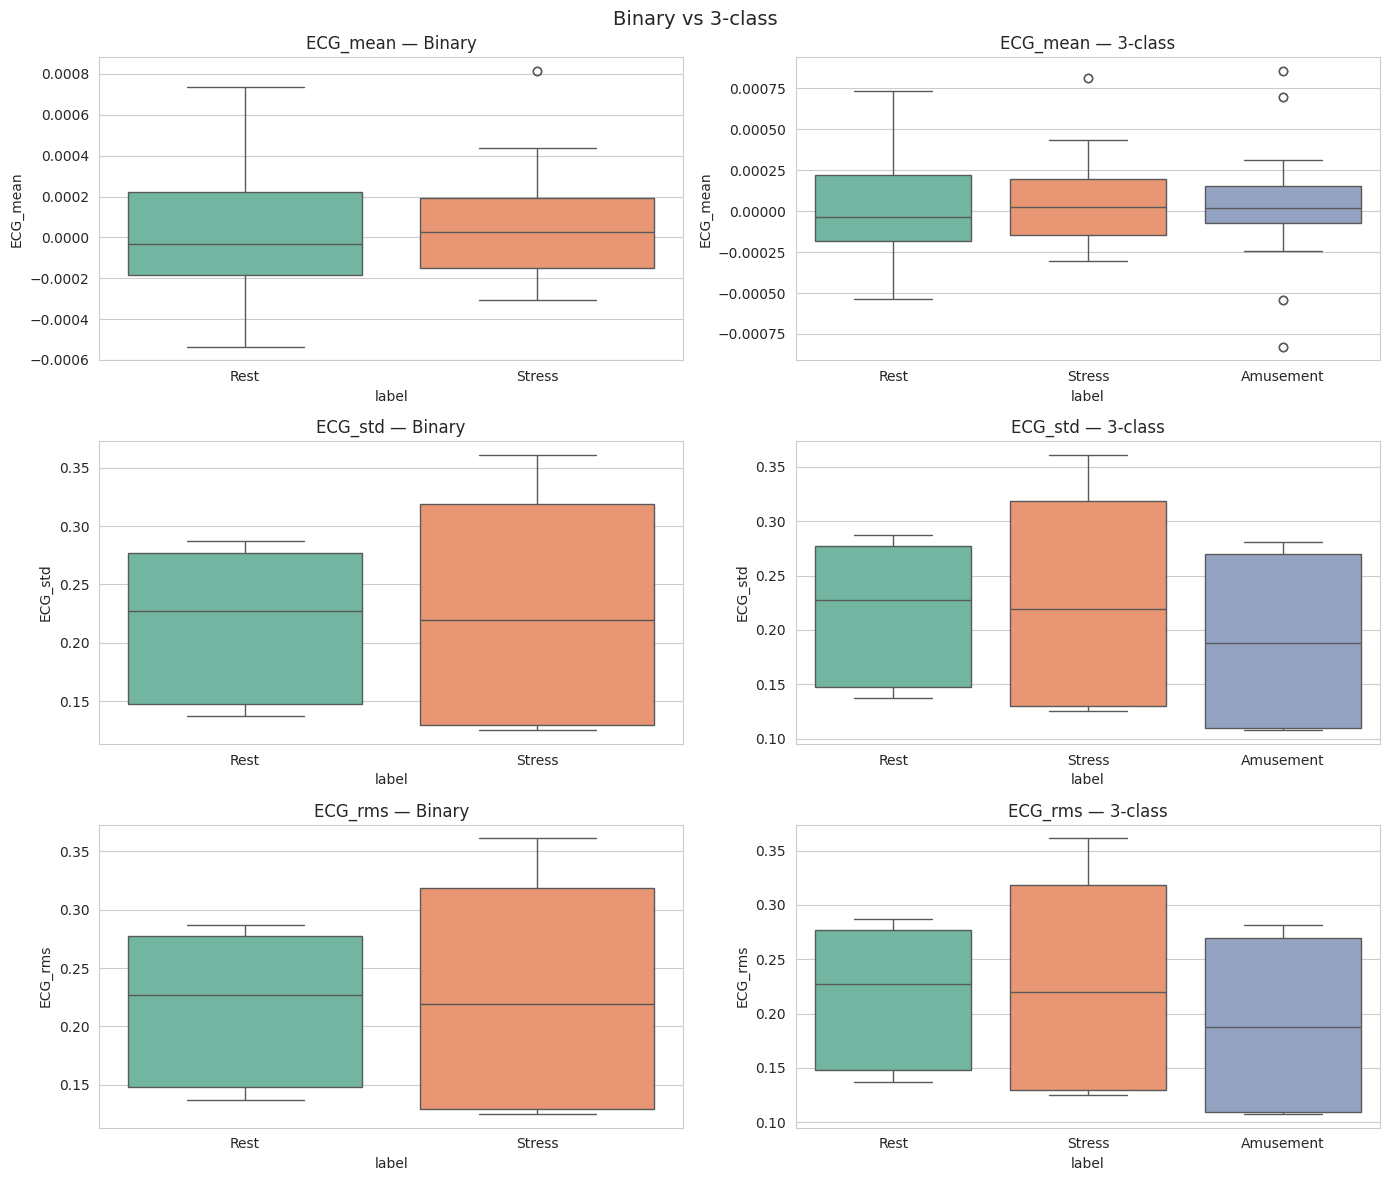

In [142]:
# ── Visual comparison ──────────────────────────────────────────
plot_feats = feat_all[:3]  # pick first 3 features
fig, axes = plt.subplots(len(plot_feats), 2, figsize=(14, 4*len(plot_feats)))
for i, feat in enumerate(plot_feats):
    if feat in df_bin_all.columns:
        sns.boxplot(data=df_bin_all, x='label', y=feat, ax=axes[i,0],
                    palette='Set2', hue='label', legend=False)
        axes[i,0].set_title(f'{feat} — Binary')
        axes[i,0].set_xticklabels(['Rest','Stress'])
    if feat in df_3cl_all.columns:
        sns.boxplot(data=df_3cl_all, x='label', y=feat, ax=axes[i,1],
                    palette='Set2', hue='label', legend=False)
        axes[i,1].set_title(f'{feat} — 3-class')
        axes[i,1].set_xticklabels(['Rest','Stress','Amusement'])
plt.suptitle('Binary vs 3-class', fontsize=14)
plt.tight_layout();  plt.show()


---
## Section 10 — Wrap-up

| Step | Technique | Applied to | Key decision |
|------|-----------|-----------|--------------|
| Quality check | NaN/Inf inspection | All signals | Build good habits |
| Imputation | Mean, median, mean±noise, interpolation | Simulated gaps | Interpolation best for temporal data |
| Outlier detection | Z-score, IQR (cautionary), windowed artifact detection | ECG | Global detection destroys R-peaks; windowed preserves physiology |
| Filtering | Butterworth bandpass/lowpass | ECG, EDA | `filtfilt` for zero-phase |
| Resampling | `scipy.signal.resample` | Wrist → 64 Hz | Enables multi-signal fusion |
| Normalisation | Z-score, min-max | All signals | Z-score typical for ML |
| Segmentation | Sliding window, 50% overlap | All, 30s | Overlap increases data |
| Feature extraction | Generic (time+freq) + domain (HR, HRV, EDA decomposition) | All segments | Domain features capture physiological meaning |
| Feature selection | Variance, correlation, t-test, MI, mRMR | Feature matrix | Multiple methods for robustness |
| Dim. reduction | PCA, t-SNE | Feature matrix | PCA for computation; t-SNE for visualization |

### Files produced
- `wesad_features_binary_all.csv` / `wesad_features_3class_all.csv`
- `wesad_features_binary_corr.csv` / `_stat.csv` / `_mi.csv`

→ These are the **input for Lab 2** (ML classification).

---
## Section 11 *(Optional)* — EDA: Chest vs Wrist Comparison

⏱ **Estimated time: 15–20 min** · TODO 16

The WESAD dataset captures EDA from **two locations**: the RespiBAN chest sensor (700 Hz) and the Empatica E4 wrist sensor (4 Hz). These measure the same physiological phenomenon (electrodermal activity) but differ in:
- sampling rate
- skin location (chest vs palmar wrist)
- sensor technology  

**Your task:** Compare the two EDA signals through the full preprocessing pipeline and see whether they provide similar or complementary information for stress detection.

### Steps to implement:

1. **Preprocess chest EDA:** apply lowpass filtering at 1 Hz (using your `apply_lowpass_filter`)
2. **Resample** chest EDA from 700 Hz → 64 Hz so both signals are at the same rate
3. **Segment** both EDA signals (30 s windows, 50% overlap)
4. **Extract features** from both (reuse `extract_time_features` + `extract_freq_features`)
5. **Visualise:**
   - Overlay plot of chest vs wrist EDA (Rest, first 2 minutes)
   - Box plots comparing a few key features between chest and wrist for Rest vs Stress
   - Correlation matrix between chest-EDA features and wrist-EDA features
6. **Interpret:** Which sensor captures stress better? Are the features complementary or redundant?


In [ ]:
# ── TODO 16: EDA Chest vs Wrist — implement your analysis here ─

# Step 1: Preprocess chest EDA (lowpass filter at 1.0 Hz)


# Step 2: Resample chest EDA to FS_TARGET


# Step 3: Segment both signals


# Step 4: Extract features for both sensors and both conditions
# Use a prefix like 'EDA_chest_' and 'EDA_wrist_' to distinguish


# Step 5: Visualise
# 5a. Overlay time plot (first 2 min of Rest: chest vs wrist)


# 5b. Box plots: pick 3-4 features, compare chest vs wrist for each condition


# 5c. Correlation between chest features and wrist features


# Step 6: Interpretation (write your answers in a markdown cell below)


### 🤔 Interpretation

1. **Which sensor (chest vs wrist) shows better separability between Rest and Stress?**
2. **Are the features from the two sensors correlated? Would you include both in a classifier or only one?**
3. **What are the practical implications of sensor placement for a real-world stress monitoring system?**

*Your answers:*

1. ...
2. ...
3. ...


---

*End of Lab 1*